## **CQF Exam 3**

# **(I) Project Objectives**
<p>
The objective of this project is to develop a model to predict positive market moves on SPDR Gold Shares (Ticker: GLD) using Machine Learning (ML) techniques.
</p>

<p>
GLD is one of the largest exchange-traded funds (ETF) by asset under management (AUM), designed to track the spot price of physical gold. It was selected for several reasons: the ETF has two decades of trading history with ample data availability, maintains a high daily transaction volume, and its underlying asset is sensitive to macroeconomic factors — making it a strong candidate for ML classification with rich features to explore.
</p>
<p>
A five-year horizon from 2020-01-01 to 2025-12-31 is used, covering multiple macroeconomic regimes including the COVID-19 crash, the zero-rate era, the aggressive rate-hike cycle and the subsequent policy pivot.
</p>
<p>
Short-term asset returns are typically characterized by low-signal to noise ratios, potentially filled with small near-zero returns. Overfitting is therefore key risk, and XGBoost addresses this issue by incorporating a regularized objective function which combines the training loss with explicit penalties on tree structure (γ) and leaf weights (λ), discouraging the model from memorizing the noise in training data. XGBoost also has built-in early stopping, parallel tree construction and ability to handle missing values, making it a well-suited for multi-sourced, large feature sets which will be used in this study.
</p>
<p>
The success criteria is to maximize ROC-AUC. The model will also be evaluated using the F1 score, confusion matrix, and full classification report to identify optimal model parameters. The practical aim is to produce a model that achieves classification accuracy above 50% and generates tradable signals with potential for positive returns after deducting transaction costs.
</p>

## **A) Explanation of Entropy in Classification**
<p>
What does entropy reveal about the quality of the partitions in a classifiation problem?
</p>

Entropy measures the impurity or uncertainty of a partition in a classification problem. The formula is:

$$H(S) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

where:
- $C$ = number of classes
- $p_i$ = proportion of observations in class $i$ inside the partition
- $\log_2$ means log base 2
<br>
<p>
For binary classification, where classes are 0 and 1:
</p>
$$H(S) = -p \log_2(p) - (1-p) \log_2(1-p)$$
<br>
where $p$ is the proportion of class 1, and $1-p$ is the proportion of class 0.
<br>
<p>
A pure partition, where all observations belong to one class, entropy equal to zero because the partition is perfectly pure. At the other extreme is when entropy is at max where observations and its split is basically 50/50. </p><br>

| Class mix in partition | Entropy | Meaning |
|:---|:---|:---|
| 100% / 0% i.e. $-1.0\log_2(1.0) - 0\log_2(0)$ | 0 | Pure |
| 90% / 10% i.e. $-0.9\log_2(0.9) - 0.1\log_2(0.1)$ | 0.469 | Mostly pure |
| 70% / 30% i.e. $-0.7\log_2(0.7) - 0.3\log_2(0.3)$ | 0.881 | Some impurity |
| 50% / 50% i.e. $-0.5\log_2(0.5) - 0.5\log_2(0.5)$ | 1.000 | Most impure |

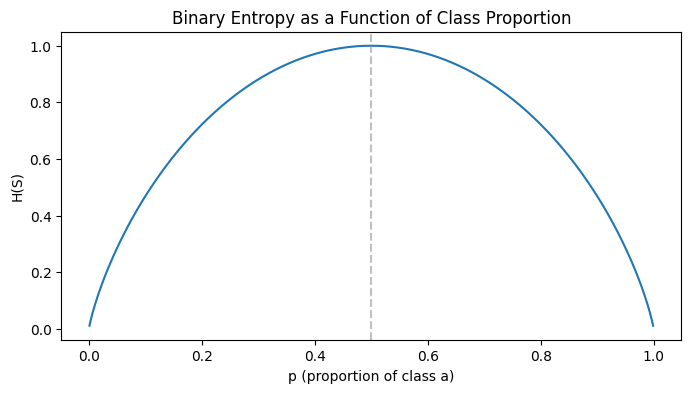

In [342]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.001, 0.999, 500)
H = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

plt.figure(figsize=(8, 4))
plt.plot(p, H)
plt.xlabel('p (proportion of class a)')
plt.ylabel('H(S)')
plt.title('Binary Entropy as a Function of Class Proportion')
plt.axvline(x=0.5, linestyle='--', color='grey', alpha=0.5)
plt.show()

(a) High entropy means the partitions are pure - **False**
<p>
High entropy in this scenario would mean in the binary classification, classes (0, 1) are almost evenly split, meaning we are uncertain which class an observation should belong to, it is impure. </p>

(b) High entropy means the partitions are impure - **True**
<p>
As we just walked through in the above where high entropy is where classes (0, 1) is observed in different classes. Maximum entropy occurs when classes are evenly split and that signals partitions are impure. A good decision-tree split should reduce entropy in the child nodes, producing higher information gain. The information gain formula is defined as follow:
</p>

$$IG = H(\text{parent}) - \frac{|S_L|}{|S|} H(S_L) - \frac{|S_R|}{|S|} H(S_R)$$

<p>
At every tree split, the algorithm aims to select a split that maximizes IG, driving child nodes toward lower entropy (purer partitions).
</p>

<p>
Applying this to the GLD price direction prediction, each split with XGBoost will seek to separate positive-move days from negative-move days as cleanly as possible, reducing entropy at each node.
</p>


## **(II) Data Collection**

A range of factors impact spot gold and GLD price. Broadly, these are the key categories:

1) Macroeconomic Factors – economic cycles, inflation expectations, central bank reserves and policies, credit conditions

2) Yields/ Currency – policy rates (fed funds), treasury yields across the curve(real and nominal), yield curve shape, USD index, especially majority of gold is transacted in USD

3) Asset Price, Cross-Asset and Positioning – GLD technicals (e.g. momentum, volatility, transaction volume, Bollinger Bands), gold to silver ratio, gold miner (GDX), equity index (SPY), bond ETFs (TLT), options/ futures position (speculative positioning from CFTC COT data)

4) Geopolitics and Risk Sentiment – VIX, equities drawdown, credit spreads (as proxy for market stress), war (e.g. Ukraine, Iran war), central bank policies (often country specific, geopolitical decision to increase gold holdings as a hedge or reserve)

Not all factors are accessible from public data sources, nor are they suitable. For example, certain gold price drivers such as wars, sanctions, central bank policy shifts are one-off/ structural change in nature; supply-side dynamics (e.g. miners output, refinery capacity) impact a much longer horizon. These are either too low in frequency or too lagged for daily directional classification or one-off events which is difficult to model. Therefore we will focus on extracting data from public sources such as Yahoo Finance, Federal Reserve Bank of St. Louis (FRED) and CFTC Commitments of Traders (COT).

Data extraction will cover approximately 5 years, aiming to ensure multiple market regimes are covered (COVID crisis, zero rate period, rate hike cycle, subsequent pivot). Data will be extracted for factors believed to impact the underlying asset, with features to be engineered after data extraction, initial EDA but before funneling into a more realistic features pipeline.


Full feature list includes:

| Source | Series | Description | Theme |
|:-------|:-------|:------------|:------|
| Yahoo Finance | GLD | SPDR Gold Shares ETF (OHLCV) | Underlying |
| | SLV | iShares Silver Trust | Cross-asset |
| | GDX | VanEck Gold Miners ETF | Cross-asset |
| | TLT | iShares 20+ Year Treasury Bond | Yields |
| | SPY | S&P 500 ETF | Risk sentiment |
| FRED | DGS10 | 10-Year Treasury yield | Yields |
| | DFII10 | 10-Year TIPS yield (real) | Yields |
| | T10YIE | 10-Year breakeven inflation | Macro |
| | T10Y2Y | 10Y–2Y yield curve spread | Yields |
| | DFF | Federal funds effective rate | Macro |
| | DTWEXBGS | Broad trade-weighted USD index | Currency |
| | VIXCLS | CBOE VIX | Risk sentiment |
| | BAMLC0A0CM | ICE BofA US corporate spread | Risk sentiment |
| | DCOILWTICO | WTI crude oil price | Macro |
| CFTC COT | Gold futures | Spec long/short, commercial, OI | Positioning |

**a) Install Packages & Import Libraries**

In [412]:
# Install packages
!pip install -q cot_reports yfinance fredapi
!pip install -q xgboost wandb pyfolio-reloaded
!pip install -q shap
!pip install -q scikit-optimize

In [344]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

# Change directory
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/CQF")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [345]:
# For data wrangling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For features data extraction
import yfinance as yf
from fredapi import Fred
from cot_reports import cot_year

# For ML
import shap
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from scipy.stats import uniform, randint

**b) Data Extraction**

i) Yahoo Finance

In [346]:
# Data Extraction from Yahoo Finance

# Define tickers and date range
tickers     = ['GLD', 'SLV', 'GDX', 'TLT', 'SPY']
start_date  = '2019-06-01'  # buffer before 2020-01-01 for rolling window warmup
end_date    = '2025-12-31'

# File save path
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data'

# GLD: full Adjusted OHLCV (needed for technical features)
df_gld = yf.download('GLD', start=start_date, end=end_date, auto_adjust=True, progress=False)
df_gld.columns = [f'GLD_{col}' for col in df_gld.columns.get_level_values('Price')]

# Cross-asset tickers: Adjusted Close only
cross_tickers = ['SLV', 'GDX', 'TLT', 'SPY']
df_cross = yf.download(cross_tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)['Close']
df_cross.columns = [f'{col}_Close' for col in df_cross.columns]

# Merge into one flat DataFrame and save to google drive
df_yf = pd.concat([df_gld, df_cross], axis=1)
df_yf.to_csv(os.path.join(SAVE_PATH, 'raw_yfinance.csv'))

In [347]:
# High level Data Quality Check
print(f"Shape: {df_yf.shape}")
print(f"Date range: {df_yf.index.min()} to {df_yf.index.max()}")
print(f"\nMissing values:\n{df_yf.isnull().sum()}")

Shape: (1655, 9)
Date range: 2019-06-03 00:00:00 to 2025-12-30 00:00:00

Missing values:
GLD_Close     0
GLD_High      0
GLD_Low       0
GLD_Open      0
GLD_Volume    0
GDX_Close     0
SLV_Close     0
SPY_Close     0
TLT_Close     0
dtype: int64


In [348]:
print(f"\nColumns: {df_yf.columns.tolist()}")
df_yf.head()


Columns: ['GLD_Close', 'GLD_High', 'GLD_Low', 'GLD_Open', 'GLD_Volume', 'GDX_Close', 'SLV_Close', 'SPY_Close', 'TLT_Close']


,GLD_Close,GLD_High,GLD_Low,GLD_Open,GLD_Volume,GDX_Close,SLV_Close,SPY_Close,TLT_Close
Date,,,,,,,,,
2019-06-03,125.110001,125.339996,123.900002,124.089996,14173600,20.727974,13.87,247.342178,108.584061
2019-06-04,125.150002,125.419998,124.610001,124.879997,7997100,20.820139,13.89,252.711258,107.346001
2019-06-05,125.470001,126.370003,125.239998,126.180000,7637900,20.857006,13.88,254.900177,106.739311
2019-06-06,125.879997,126.449997,125.800003,125.930000,5551800,21.078203,13.92,256.557770,107.083672
2019-06-07,126.589996,127.250000,126.320000,126.790001,8145900,21.096636,14.06,259.125153,108.010124


ii) FRED

In [349]:
# FRED API key from Colab Secrets
from google.colab import userdata
fred = Fred(api_key=userdata.get('FRED'))

# Date Parameters
start_date  = '2019-06-01'  # buffer before 2020-01-01 for rolling window warmup
end_date = '2025-12-31'

# File save path
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data'

# Define FRED series
fred_series = {
    'DGS10':      '10-Year Treasury Yield',
    'DFII10':     '10-Year TIPS (Real Yield)',
    'T10YIE':     '10-Year Breakeven Inflation',
    'T10Y2Y':     'Yield Curve (10Y-2Y)',
    'DFF':        'Fed Funds Effective Rate',
    'DTWEXBGS':   'Broad Trade-Weighted USD Index',
    'VIXCLS':     'CBOE VIX',
    'BAMLC0A0CM': 'ICE BofA US Corporate Spread',
    'DCOILWTICO': 'WTI Crude Oil',
}

# Download each series
df_fred = pd.DataFrame()
for code, desc in fred_series.items():
    try:
        s = fred.get_series(code, observation_start=start_date, observation_end=end_date)
        df_fred[code] = s
    except Exception as e:
        print(f"  {code:15s} FAILED: {e}")

df_fred.to_csv(os.path.join(SAVE_PATH, 'raw_fred.csv'))

In [350]:
# High level Data Quality Check
print(f"\nShape: {df_fred.shape}")
print(f"Date range: {df_fred.index.min()} to {df_fred.index.max()}")
print(f"\nMissing values:\n{df_fred.isnull().sum()}")


Shape: (1718, 9)
Date range: 2019-06-03 00:00:00 to 2025-12-31 00:00:00

Missing values:
DGS10           72
DFII10          72
T10YIE          72
T10Y2Y          72
DFF              0
DTWEXBGS        74
VIXCLS          35
BAMLC0A0CM    1043
DCOILWTICO      72
dtype: int64


In [351]:
print(f"\nColumns: {df_fred.columns.tolist()}")
display(df_fred.head())


Columns: ['DGS10', 'DFII10', 'T10YIE', 'T10Y2Y', 'DFF', 'DTWEXBGS', 'VIXCLS', 'BAMLC0A0CM', 'DCOILWTICO']


,DGS10,DFII10,T10YIE,T10Y2Y,DFF,DTWEXBGS,VIXCLS,BAMLC0A0CM,DCOILWTICO
2019-06-03,2.07,0.34,1.73,0.25,2.38,116.4764,18.86,NaN,53.25
2019-06-04,2.12,0.38,1.74,0.24,2.38,116.0910,16.97,NaN,53.50
2019-06-05,2.12,0.37,1.75,0.29,2.38,116.0300,16.09,NaN,51.57
2019-06-06,2.12,0.39,1.73,0.24,2.37,115.9771,15.93,NaN,52.59
2019-06-07,2.09,0.35,1.74,0.24,2.37,115.7368,16.30,NaN,53.95


iii) CFTC COT

In [352]:
# File save path
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data'

# Columns to keep and their clean names
cot_cols = {
    'Open Interest (All)'                 :'COT_OI',
    'Noncommercial Positions-Long (All)'  :'COT_Spec_Long',
    'Noncommercial Positions-Short (All)' :'COT_Spec_Short',
    'Commercial Positions-Long (All)'     :'COT_Comm_Long',
    'Commercial Positions-Short (All)'    :'COT_Comm_Short',
}

# Download, filter Gold, select columns
# date range to extract reports
years = range(2019, 2026)

frames = []
for year in years:
    df = cot_year(year, cot_report_type='legacy_fut')
    gold = df[df['Market and Exchange Names'].str.contains('GOLD', case=False)]
    frames.append(gold)

df_cot_gold = (
    pd.concat(frames, ignore_index=True)
    .assign(Date=lambda d: pd.to_datetime(d['As of Date in Form YYYY-MM-DD']))
    .set_index('Date')
    .sort_index()
    [list(cot_cols.keys())]
    .rename(columns=cot_cols)
    .apply(pd.to_numeric, errors='coerce')
)

df_cot_gold.to_csv(os.path.join(SAVE_PATH, 'raw_cot_gold.csv'))

Selected: legacy_fut
Downloaded single year data from: 2019
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2020
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2021
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2022
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2023
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2024
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2025
Stored the file annual.txt in the working directory.


In [353]:
# High level Data Quality Check
print(f"\nShape: {df_cot_gold.shape}")
print(f"Date range: {df_cot_gold.index.min()} to {df_cot_gold.index.max()}")
print(f"\nMissing values:\n{df_cot_gold.isnull().sum()}")


Shape: (492, 5)
Date range: 2019-01-08 00:00:00 to 2025-12-30 00:00:00

Missing values:
COT_OI            0
COT_Spec_Long     0
COT_Spec_Short    0
COT_Comm_Long     0
COT_Comm_Short    0
dtype: int64


In [354]:
df_cot_gold.head()

,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,
2019-01-08,455232,199560,100344,137605,258792
2019-01-15,501605,201796,113883,179059,287172
2019-01-22,513509,186510,112006,197278,289355
2019-01-29,483390,212318,112725,163922,282531
2019-02-05,479736,218200,109105,157588,288830


c) Data Cleaning

i) Examining NAN values in FRED df

At a first pass, FRED data has NAN values, with BAMLC0A0CM (credit Spread) missing 900+ bars. Investigation required.

In [355]:
print("\nSample of NaN dates across yield series:")
nan_dates = df_fred[df_fred['DGS10'].isnull()].index[:10]
print(nan_dates)

print("\n\nBAMLC0A0CM (credit spread) — first valid date:")
df_fred['BAMLC0A0CM'].first_valid_index()




Sample of NaN dates across yield series:
DatetimeIndex(['2019-07-04', '2019-09-02', '2019-10-14', '2019-11-11',
               '2019-11-28', '2019-12-25', '2020-01-01', '2020-01-20',
               '2020-02-17', '2020-04-10'],
              dtype='datetime64[ns]', freq=None)


BAMLC0A0CM (credit spread) — first valid date:


Timestamp('2023-05-22 00:00:00')

On FRED NAN dates - dates listed above, are non-trading days. This will be adjsuted with ffill, same process for other data sources. <br>

Re BAMLC0A0CM (Credit spread), this data series it not usable for ML training as there is insufficient data, earliest start date only in 2023-05-22 leaving us 2.5 years of data for training and testing. <br>

ICE BofA US High Yield Index Option-Adjusted Spread data has been explored as an alternative. However, we encountered same issue where earliest data availability only starts from 2023-05. <br>

Conclusion: BAMLC0A0CM is dropped from the FRED dataset and replaced with Moody's BAA Corporate Bond Yield (DBAA), The credit spread will become an engineered feature using BAA yield minus 10-Year Treasury. This will be addressed in the feature engineering process.


In [356]:
# Replace credit spread series with Moody's BAA yield
df_fred = df_fred.drop(columns=['BAMLC0A0CM'])
df_fred['DBAA'] = fred.get_series('DBAA', observation_start='2019-12-01', observation_end='2025-12-31')

print(f"Shape: {df_fred.shape}")
print(f"\nMissing values:\n{df_fred.isnull().sum()}")

Shape: (1718, 9)

Missing values:
DGS10          72
DFII10         72
T10YIE         72
T10Y2Y         72
DFF             0
DTWEXBGS       74
VIXCLS         35
DCOILWTICO     72
DBAA          198
dtype: int64


In [357]:
print(f"Duplicate dates: {df_cot_gold.index.duplicated().sum()}")
print(f"\nDuplicate rows:")
display(df_cot_gold[df_cot_gold.index.duplicated(keep=False)].head(10))

Duplicate dates: 127

Duplicate rows:


,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,
2020-12-01,32377,15096,13979,0,0
2020-12-01,538042,324344,64030,110108,403371
2020-12-29,556414,341812,72940,101283,408537
2020-12-29,34210,15798,22384,0,0
2021-05-18,33854,10031,12915,0,0
2021-05-18,520410,290267,91378,121839,354740
2021-08-17,485485,284437,92895,123301,337301
2021-08-17,32480,14107,8528,0,0
2021-09-07,34633,8491,9756,0,0


ii) merge all df together for further data cleaning and pre-processing

In [358]:
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data/'

# Load raw data
# df_yf = pd.read_csv(SAVE_PATH + 'raw_yfinance.csv', index_col=0, parse_dates=True)
# df_fred = pd.read_csv(SAVE_PATH + 'raw_fred.csv', index_col=0, parse_dates=True)
# df_cot = pd.read_csv(SAVE_PATH + 'raw_cot_gold.csv', index_col=0, parse_dates=True)

# Step 1: GLD trading dates = master calendar
master_idx = df_yf.index

# Step 2: Reindex FRED to GLD calendar, forward-fill
df_fred_aligned = df_fred.reindex(master_idx).ffill()

# Step 3: Reindex COT to GLD calendar, forward-fill
# Remove duplicate dates (aggregate if multiple gold contracts per week)
df_cot_dedup = df_cot_gold.groupby(df_cot_gold.index).sum()

# COT is Tuesday snapshot, published Friday — shift forward 4 business days
# so the model first sees it on the following Monday (no lookahead bias)
df_cot_aligned = (
    df_cot_dedup
    .shift(freq=pd.tseries.offsets.BDay(4))  # Tue → next Mon
    .reindex(master_idx)
    .ffill()
)

# Step 4: Merge all into one DataFrame
df_merged = pd.concat([df_yf, df_fred_aligned, df_cot_aligned], axis=1)

In [359]:
# High level data audit
print(f"Shape: {df_merged.shape}")
print(f"Date range: {df_merged.index.min()} to {df_merged.index.max()}")
print(f"\nMissing values:\n{df_merged.isnull().sum()}")
print(f"\nTotal NaN: {df_merged.isnull().sum().sum()}")

Shape: (1655, 23)
Date range: 2019-06-03 00:00:00 to 2025-12-30 00:00:00

Missing values:
GLD_Close           0
GLD_High            0
GLD_Low             0
GLD_Open            0
GLD_Volume          0
GDX_Close           0
SLV_Close           0
SPY_Close           0
TLT_Close           0
DGS10               0
DFII10              0
T10YIE              0
T10Y2Y              0
DFF                 0
DTWEXBGS            0
VIXCLS              0
DCOILWTICO          0
DBAA              127
COT_OI              0
COT_Spec_Long       0
COT_Spec_Short      0
COT_Comm_Long       0
COT_Comm_Short      0
dtype: int64

Total NaN: 127


In [360]:
df_merged.head()

,GLD_Close,GLD_High,GLD_Low,GLD_Open,GLD_Volume,GDX_Close,SLV_Close,SPY_Close,TLT_Close,DGS10,...,DFF,DTWEXBGS,VIXCLS,DCOILWTICO,DBAA,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,,,,,,,,,,,,,,,,,
2019-06-03,125.110001,125.339996,123.900002,124.089996,14173600,20.727974,13.87,247.342178,108.584061,2.07,...,2.38,116.4764,18.86,53.25,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-04,125.150002,125.419998,124.610001,124.879997,7997100,20.820139,13.89,252.711258,107.346001,2.12,...,2.38,116.0910,16.97,53.50,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-05,125.470001,126.370003,125.239998,126.180000,7637900,20.857006,13.88,254.900177,106.739311,2.12,...,2.38,116.0300,16.09,51.57,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-06,125.879997,126.449997,125.800003,125.930000,5551800,21.078203,13.92,256.557770,107.083672,2.12,...,2.37,115.9771,15.93,52.59,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-07,126.589996,127.250000,126.320000,126.790001,8145900,21.096636,14.06,259.125153,108.010124,2.09,...,2.37,115.7368,16.30,53.95,NaN,505126.0,194463.0,107775.0,191290.0,301244.0


In [361]:
# Sanity check if there are 0 left in columns
print("Zero counts per column:")
print((df_merged == 0).sum())
print(f"\nDescriptive stats:")
display(df_merged.describe().T)

Zero counts per column:
GLD_Close         0
GLD_High          0
GLD_Low           0
GLD_Open          0
GLD_Volume        0
GDX_Close         0
SLV_Close         0
SPY_Close         0
TLT_Close         0
DGS10             0
DFII10            5
T10YIE            0
T10Y2Y            7
DFF               0
DTWEXBGS          0
VIXCLS            0
DCOILWTICO        0
DBAA              0
COT_OI            0
COT_Spec_Long     0
COT_Spec_Short    0
COT_Comm_Long     0
COT_Comm_Short    0
dtype: int64

Descriptive stats:


,count,mean,std,min,25%,50%,75%,max
GLD_Close,1655.0,1.976096e+02,5.855638e+01,1.251100e+02,1.649200e+02,1.770800e+02,2.152850e+02,4.167400e+02
GLD_High,1655.0,1.984801e+02,5.884390e+01,1.253400e+02,1.656500e+02,1.776100e+02,2.160600e+02,4.184500e+02
GLD_Low,1655.0,1.966182e+02,5.810977e+01,1.239000e+02,1.641850e+02,1.763700e+02,2.144450e+02,4.147500e+02
GLD_Open,1655.0,1.975944e+02,5.853727e+01,1.240900e+02,1.649950e+02,1.769600e+02,2.152900e+02,4.164800e+02
GLD_Volume,1655.0,9.201960e+06,5.354843e+06,1.436500e+06,5.807650e+06,7.888300e+06,1.093500e+07,6.202500e+07
GDX_Close,1655.0,3.449188e+01,1.197084e+01,1.763556e+01,2.768083e+01,3.125663e+01,3.643499e+01,9.129000e+01
SLV_Close,1655.0,2.358957e+01,7.378327e+00,1.121000e+01,1.973000e+01,2.220000e+01,2.586000e+01,7.112000e+01
SPY_Close,1655.0,4.245402e+02,1.141256e+02,2.049449e+02,3.477248e+02,4.068073e+02,5.076161e+02,6.884997e+02
TLT_Close,1655.0,1.038547e+02,1.955101e+01,7.426588e+01,8.623775e+01,9.497375e+01,1.210780e+02,1.437899e+02
DGS10,1655.0,2.853873e+00,1.381999e+00,5.200000e-01,1.570000e+00,3.370000e+00,4.170000e+00,4.980000e+00


In [362]:
# save merged file to data folder
df_merged.to_csv(os.path.join(SAVE_PATH, 'cleaned_merged.csv'))

## **(III) EDA**

In [363]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/cleaned_merged.csv', index_col=0, parse_dates=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: (1655, 23)
Date range: 2019-06-03 00:00:00 to 2025-12-30 00:00:00
Missing values: 127


,GLD_Close,GLD_High,GLD_Low,GLD_Open,GLD_Volume,GDX_Close,SLV_Close,SPY_Close,TLT_Close,DGS10,...,DFF,DTWEXBGS,VIXCLS,DCOILWTICO,DBAA,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,,,,,,,,,,,,,,,,,
2019-06-03,125.110001,125.339996,123.900002,124.089996,14173600,20.727974,13.87,247.342178,108.584061,2.07,...,2.38,116.4764,18.86,53.25,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-04,125.150002,125.419998,124.610001,124.879997,7997100,20.820139,13.89,252.711258,107.346001,2.12,...,2.38,116.0910,16.97,53.50,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-05,125.470001,126.370003,125.239998,126.180000,7637900,20.857006,13.88,254.900177,106.739311,2.12,...,2.38,116.0300,16.09,51.57,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-06,125.879997,126.449997,125.800003,125.930000,5551800,21.078203,13.92,256.557770,107.083672,2.12,...,2.37,115.9771,15.93,52.59,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-07,126.589996,127.250000,126.320000,126.790001,8145900,21.096636,14.06,259.125153,108.010124,2.09,...,2.37,115.7368,16.30,53.95,NaN,505126.0,194463.0,107775.0,191290.0,301244.0


In [364]:
# Descriptive statistics
df.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
GLD_Close,1655.00,197.61,58.56,125.11,164.92,177.08,215.29,416.74
GLD_High,1655.00,198.48,58.84,125.34,165.65,177.61,216.06,418.45
GLD_Low,1655.00,196.62,58.11,123.90,164.18,176.37,214.44,414.75
GLD_Open,1655.00,197.59,58.54,124.09,165.00,176.96,215.29,416.48
GLD_Volume,1655.00,9201959.70,5354842.78,1436500.00,5807650.00,7888300.00,10935000.00,62025000.00
GDX_Close,1655.00,34.49,11.97,17.64,27.68,31.26,36.43,91.29
SLV_Close,1655.00,23.59,7.38,11.21,19.73,22.20,25.86,71.12
SPY_Close,1655.00,424.54,114.13,204.94,347.72,406.81,507.62,688.50
TLT_Close,1655.00,103.85,19.55,74.27,86.24,94.97,121.08,143.79
DGS10,1655.00,2.85,1.38,0.52,1.57,3.37,4.17,4.98


Descriptive statistics are revealing vastly different scales across the raw columns - from single digit yields percentages to trading volume in millions. This confirms that raw features will need to be transformed, normalized and engineered.

In [365]:
# Verify continuous trading day index (no unexpected gaps)
date_diffs = df.index.to_series().diff().dt.days
print(f"Min gap: {date_diffs.min()} days")
print(f"Max gap: {date_diffs.max()} days")
print(f"\nGap distribution:\n{date_diffs.value_counts().sort_index()}")

Min gap: 1.0 days
Max gap: 4.0 days

Gap distribution:
Date
1.0    1293
2.0      18
3.0     299
4.0      44
Name: count, dtype: int64


A date continuity check confirms no unexpected gaps in the trading day index — observed gaps of 1 to 4 calendar days correspond to weekday, weekend, and holiday patterns.

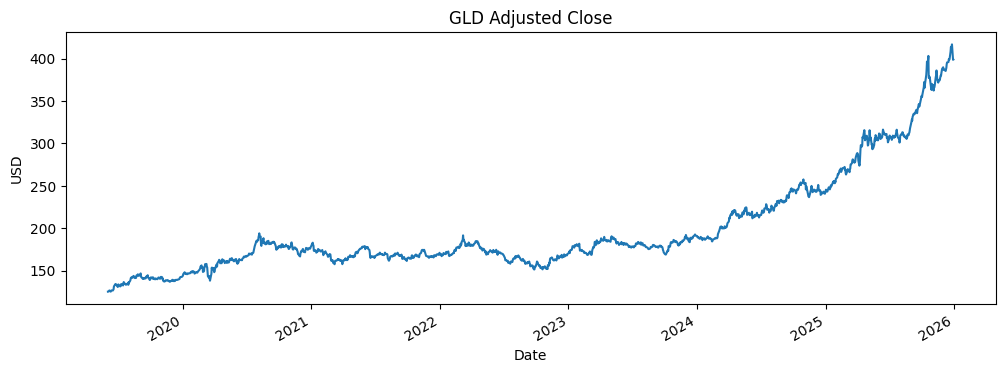

In [366]:
# GLD price history
df['GLD_Close'].plot(figsize=(12, 4), title='GLD Adjusted Close')
plt.ylabel('USD')
plt.show()

GLD has shown an upward trend, paritulcalry from mid-2024 onward. This long bias may result in a class imbalance toward positive returns, which will be examined during label construction.

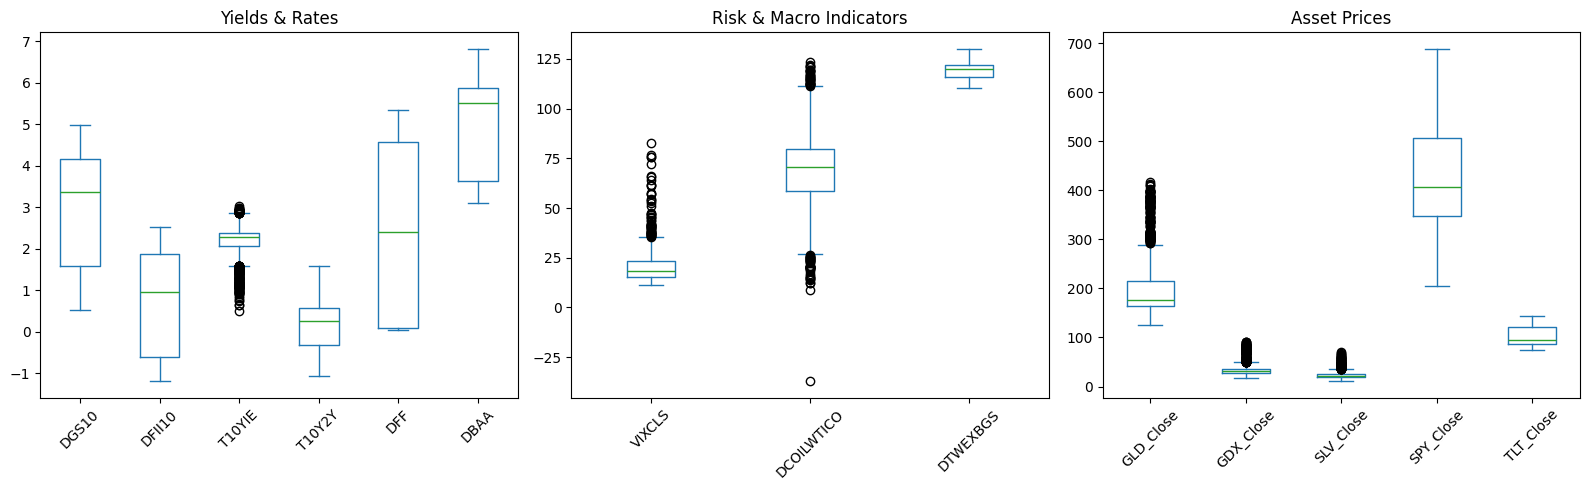

In [367]:
# Box plots — grouped by scale
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Yields & rates
df[['DGS10', 'DFII10', 'T10YIE', 'T10Y2Y', 'DFF', 'DBAA']].plot.box(ax=axes[0])
axes[0].set_title('Yields & Rates')
axes[0].tick_params(axis='x', rotation=45)

# Risk & macro
df[['VIXCLS', 'DCOILWTICO', 'DTWEXBGS']].plot.box(ax=axes[1])
axes[1].set_title('Risk & Macro Indicators')
axes[1].tick_params(axis='x', rotation=45)

# GLD OHLC only (not volume, not cross-asset)
df[['GLD_Close', 'GDX_Close', 'SLV_Close', 'SPY_Close', 'TLT_Close']].plot.box(ax=axes[2])
axes[2].set_title('Asset Prices')
# df[['GLD_Open', 'GLD_High', 'GLD_Low', 'GLD_Close']].plot.box(ax=axes[2])
# axes[2].set_title('GLD Price')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The box plots revealed notable outliers in VIX and Oil (COVID-er spike and WTI going negative in 2020). The assets – GLD, GDX, SLV all showing wide ranges with upper outliers, this matches with price breakthroughs late 2024-2025. SPY’s wide range is a good indicator we have covered different market regimes in the dataset.

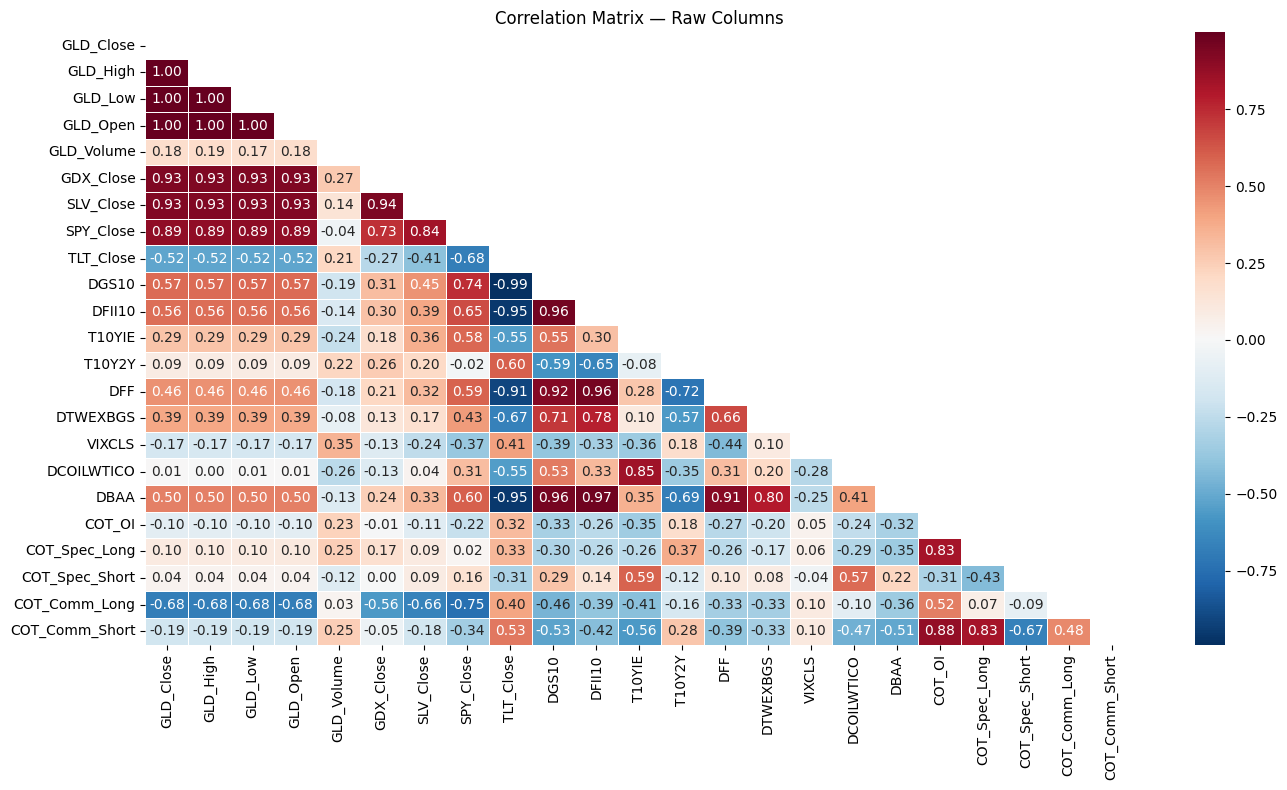

In [368]:
fig, ax = plt.subplots(figsize=(14, 8))
matrix = np.triu(df.corr())
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", linewidths=0.5, ax=ax, mask=matrix)
ax.set_title("Correlation Matrix — Raw Columns")
plt.tight_layout()
plt.show()

The raw column correlation matrix is used as an exploratory diagnostic to understand common trends, potentially redundant variables and macro regimes. At this stage, they may not signal predictive relationships. Several observations:

1) potentially redundant variables – GLD OHLC almost identical, reinforcing the need to convert into ratios, returns, z-scores etc in feature engineering and likely to be dropped afterwards
2) potentially high colinear feature groups – Cross asset ETFs, COT variables, rate variables
3) understanding on broad market structure and relationships – TLT and commercial COT positionings are strongly negatively correlated with GLD price

## **(IV) Feature Engineering**

a) Target Variable Construction

Log returns are used to compute asset returns. This transforms non-stationary price series into relative changes that are more comparable across assets with different price scales. It also allows multi-period returns to be obtained by simple summation of single-period log returns. This makes it convenient to compare returns, volatility, momentum and target-label construction.

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$$

To construct the target variable, we first compute daily log returns and first examine and understand the series from these aspects:

1) Are the returns stationary – or does it cluster around volatility clustering and regimes across peirod
2) The returns distribution profile – does it shape around zero, dominated by small moves or it looks choppy and dispersed
3) Statistical behavior – is the return series skewed, biased towards positive/ negative moves or dominated by outliers

These inform the choice of the boundary below which daily returns are treated as noise rather than genuine directional signals, and the resulting binary label assignment


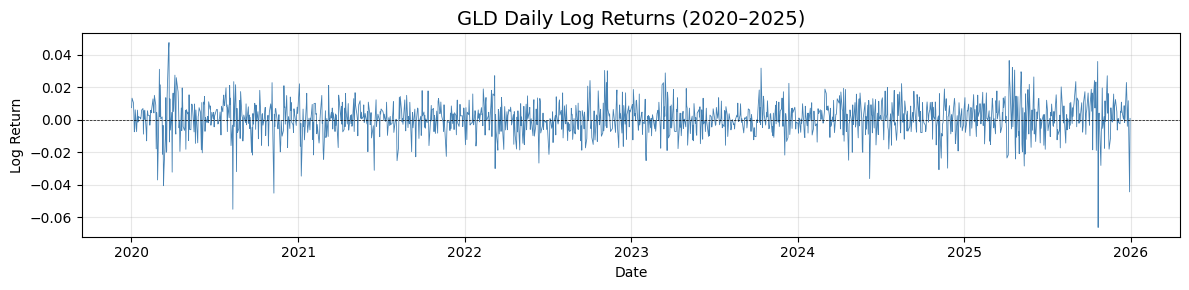

In [369]:
# Compute daily log returns from GLD adjusted close
df['GLD_LogRet'] = np.log(df['GLD_Close']).diff()

# Plot daily log returns over time
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(df.loc['2020':].index, df.loc['2020':, 'GLD_LogRet'], linewidth=0.6, color='steelblue')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('GLD Daily Log Returns (2020–2025)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Log Return')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The return distribution is examined to identify the zone/ threshold for near-zero returns that carry no meaningful directional signal.

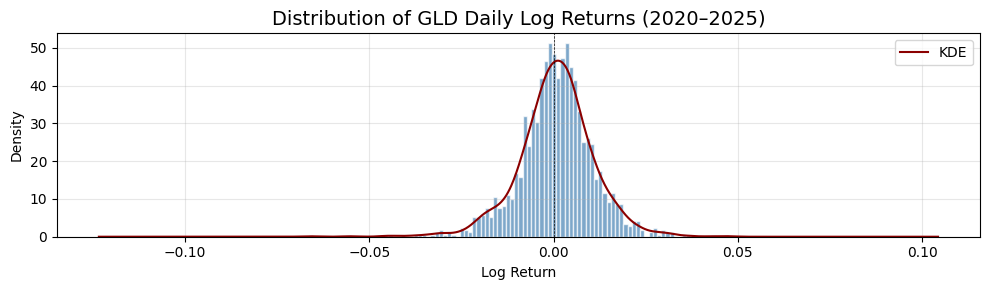

In [370]:
# Plot return distribution
ret = df.loc['2020':, 'GLD_LogRet']

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(ret, bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='white')
ret.plot.kde(ax=ax, color='darkred', linewidth=1.5, label='KDE')
ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Distribution of GLD Daily Log Returns (2020–2025)', fontsize=14)
ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [419]:
# Descriptive statistics of GLD daily log returns
ret = df.loc['2020':, 'GLD_LogRet']

stats = pd.DataFrame({
    'Statistic': ['Count', 'Mean', 'Median', 'Std Dev', 'Skewness', 'Kurtosis (excess)',
                  'Min', '5th Percentile', '25th Percentile', '75th Percentile',
                  '95th Percentile', 'Max'],
    'Value': [f"{len(ret):,.0f}", f"{ret.mean():.6f}", f"{ret.median():.6f}", f"{ret.std():.6f}", f"{ret.skew():.4f}", f"{ret.kurtosis():.4f}",
              f"{ret.min():.6f}", f"{ret.quantile(0.05):.6f}", f"{ret.quantile(0.25):.6f}", f"{ret.quantile(0.75):.6f}", f"{ret.quantile(0.95):.6f}", f"{ret.max():.6f}"]})

stats.T

,0,1,2,3,4,5,6,7,8,9,10,11
Statistic,Count,Mean,Median,Std Dev,Skewness,Kurtosis (excess),Min,5th Percentile,25th Percentile,75th Percentile,95th Percentile,Max
Value,"1,507",0.000681,0.000858,0.010309,-0.4359,3.1915,-0.066427,-0.016459,-0.004661,0.006322,0.016720,0.047390


The descriptive statistics has  a mean of 0.069%, which is trending slightly positive, potentially creating class imbalance. With the skewness at -0.44, this illustrates drawdowns are larger than upward movements. Kurtosis is also suggesting the returns sereis have fat tails. <br>

The return distribution shows a concentration of near-zero observations that require a classification decision — either exclude them from the training dataset, or reclassify them. To select an appropriate threshold, we first examine how observations fall within various bands. If we set the threshold too low, it retains noise in the labels; too high reduces the training sample and the model's ability to generalize.

In [421]:
# Count observations within candidate different thresholds
ret = df.loc['2020':, 'GLD_LogRet']
total = len(ret)
std = ret.std()

thresholds = [0.0005, 0.001, 0.0015, 0.002, 0.0025, 0.003, 0.005]

rows = []
for t in thresholds:
    in_zone = ret.abs() < t
    n_drop = in_zone.sum()
    rows.append({
        'Threshold': f'±{t:.4f} ({t*100:.2f}%)',
        'Fraction of σ': f'{t / std:.2f}σ',
        'Observations Dropped': n_drop,
        '% of Total': f'{n_drop / total * 100:.1f}%',
        'Remaining': total - n_drop
    })

threshold_df = pd.DataFrame(rows)
threshold_df

,Threshold,Fraction of σ,Observations Dropped,% of Total,Remaining
0,±0.0005 (0.05%),0.05σ,68,4.5%,1439
1,±0.0010 (0.10%),0.10σ,152,10.1%,1355
2,±0.0015 (0.15%),0.15σ,209,13.9%,1298
3,±0.0020 (0.20%),0.19σ,293,19.4%,1214
4,±0.0025 (0.25%),0.24σ,356,23.6%,1151
5,±0.0030 (0.30%),0.29σ,420,27.9%,1087
6,±0.0050 (0.50%),0.49σ,678,45.0%,829


Based on the analysis above, small positive returns below +0.0020 (0.20%) are classified as non-positive (label = 0). This treats moves within approximately 0.19 standard deviations of zero as carrying no meaningful directional signal — they are statistically indistinguishable from noise and economically marginal. It also retains the full dataset for training while producing a stricter definition of a positive move. In production, a volatility-adaptive threshold scaled to rolling local standard deviation would better account for regime shifts; for this study, a fixed threshold is used for simplicity and reproducibility.

The target variable is defined as:

$$y_t = \begin{cases} 1, & \text{if } r_{t+1} > 0.0020 \\ 0, & \text{otherwise} \end{cases}$$

where: <br>
$r_{t+1} = \ln(P_{t+1}) - \ln(P_t)$ is the next-day log return of GLD. Standing at the close of day $t$ with all available information, the model predicts whether tomorrow's return will exceed the +0.20% threshold.

In [422]:
# Construct binary target variable
# Label = 1 if log return exceeds +0.20%, else 0
df['Label'] = np.where(df['GLD_LogRet'].shift(-1) > 0.002, 1, 0)

We examine the class distribution to check for imbalance, which may require adjustment during model training.

Class 0: 829 (55.0%)
Class 1: 678 (45.0%)


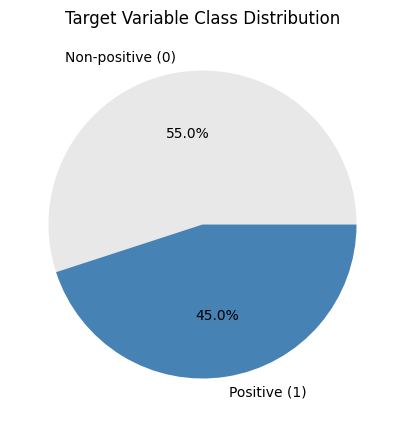

In [374]:
# Class balance
counts = df.loc['2020':, 'Label'].value_counts()
print(f"Class 0: {counts[0]} ({counts[0]/counts.sum()*100:.1f}%)")
print(f"Class 1: {counts[1]} ({counts[1]/counts.sum()*100:.1f}%)")

df.loc['2020':, 'Label'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Non-positive (0)', 'Positive (1)'],
    colors=['#E8E8E8', 'steelblue'],
    figsize=(5, 5),
    title='Target Variable Class Distribution'
)
plt.ylabel('')
plt.show()

The class distribution is approximately balanced at 55/45, with a mild skew toward non-positive outcomes following the reclassification of near-zero returns. This moderate imbalance will be addressed using balanced sample weighting during model training.

b) Feature Engineering

The feature set is organized into four thematic categories, totaling approximately 47 engineered features derived from the 23 raw columns in the dataset. The categories reflect various information channels that drive gold price:

1. **Technical** (~20 features) — Price action, momentum, volatility, and volume patterns derived from GLD OHLCV data. These capture the dynamics of gold's own price process.

2. **Cross-Asset** (~9 features) — Relative performance and co-movement with related assets (silver, gold miners, equities, treasuries).

3. **Macro** (~11 features) — Interest rates, real yields, inflation expectations, credit conditions, the US dollar, oil, and volatility. These are the fundamental drivers of gold's role as a real asset, inflation hedge, and safe haven.

4. **Positioning** (~7 features) — CFTC Commitments of Traders data capturing speculator and commercial hedger positioning in gold futures. Extreme positioning has historically preceded trend reversals.

Rolling window lengths of 7, 14, 28, and 63 trading days correspond approximately to 1-week, 2-week, 1-month, and 1-quarter horizons.

### Category 1: Technical Features (~20 features from GLD OHLCV)

Technical features extract information from GLD's own price and volume history. The core building blocks are:

- **Rolling cumulative returns** over 7, 14, 28, and 63 days capture momentum at multiple horizons.
- **Rolling volatility** (standard deviation of daily log returns) measures the dispersion of returns at each horizon. Volatility clustering — visible in the time series plot above — means recent volatility is informative about near-term return distributions.
- **Bollinger %B** normalises the closing price's position within its Bollinger Band to a 0–1 scale: $\%B = (P - LB) / (UB - LB)$.
- **Intraday structure**: the open-to-close ratio for intraday direction, high-low range proxies intraday volatility, and the overnight gap captures information flow between Asia/ European/ US markets.
- **RSI (14-day)** measures momentum. Values > 70 suggest overbought < 30 suggests oversold.
- **Volume percentage changes** capture shifts in trading activity.
- **Lagged return** (1-day) allows the model to detect any residual autocorrelation in daily returns.

In [375]:
# ── Category 1: Technical Features (~20 from GLD OHLCV) ──

# 1. Rolling cumulative log returns (4 features)
for w in [7, 14, 28, 63]:
    df[f'RollRet_{w}d'] = df['GLD_LogRet'].rolling(w).sum()

# 2. Rolling volatility — std of daily log returns (4 features)
for w in [7, 14, 28, 63]:
    df[f'RollVol_{w}d'] = df['GLD_LogRet'].rolling(w).std()

# 3. Bollinger %B — normalised band position (2 features)
for w in [14, 28]:
    sma = df['GLD_Close'].rolling(w).mean()
    std = df['GLD_Close'].rolling(w).std()
    ub = sma + 2 * std
    lb = sma - 2 * std
    df[f'BB_PctB_{w}d'] = (df['GLD_Close'] - lb) / (ub - lb)

# 4. Volume percentage change (3 features)
for w in [7, 14, 28]:
    df[f'VolChg_{w}d'] = df['GLD_Volume'].pct_change(w)

# 5. Intraday structure (3 features)
df['OC'] = (df['GLD_Close'] - df['GLD_Open']) / df['GLD_Open']    # open-to-close body
df['HL'] = (df['GLD_High'] - df['GLD_Low']) / df['GLD_Close']     # intraday range
df['GAP'] = df['GLD_Open'] / df['GLD_Close'].shift(1) - 1         # overnight gap

# 6. Rolling mean of overnight gap (1 feature)
df['GAP_14d'] = df['GAP'].rolling(14).mean()

# 7. RSI — 14-day, simple moving average variant (1 feature)
_gain = df['GLD_LogRet'].clip(lower=0)
_loss = -df['GLD_LogRet'].clip(upper=0)
_avg_gain = _gain.rolling(14).mean()
_avg_loss = _loss.rolling(14).mean()
df['RSI_14d'] = 100 - (100 / (1 + _avg_gain / _avg_loss))

# 8. Lagged return (1 feature)
df['LagRet_1d'] = df['GLD_LogRet'].shift(1)

# Clean up temp variables
del _gain, _loss, _avg_gain, _avg_loss

# ── Verify ──
cat1_features = ['GLD_LogRet', 'RollRet_7d', 'RollRet_14d', 'RollRet_28d', 'RollRet_63d', 'RollVol_7d', 'RollVol_14d', 'RollVol_28d', 'RollVol_63d', 'BB_PctB_14d', 'BB_PctB_28d',
                 'VolChg_7d', 'VolChg_14d', 'VolChg_28d', 'OC', 'HL', 'GAP', 'GAP_14d', 'RSI_14d', 'LagRet_1d']

print(f"Category 1: {len(cat1_features)} features")
df[cat1_features].head()

Category 1: 20 features


,GLD_LogRet,RollRet_7d,RollRet_14d,RollRet_28d,RollRet_63d,RollVol_7d,RollVol_14d,RollVol_28d,RollVol_63d,BB_PctB_14d,BB_PctB_28d,VolChg_7d,VolChg_14d,VolChg_28d,OC,HL,GAP,GAP_14d,RSI_14d,LagRet_1d
Date,,,,,,,,,,,,,,,,,,,,
2019-06-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008220,0.011510,NaN,NaN,NaN,NaN
2019-06-04,0.000320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002162,0.006472,-0.001838,NaN,NaN,NaN
2019-06-05,0.002554,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.005627,0.009006,0.008230,NaN,NaN,0.000320
2019-06-06,0.003262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000397,0.005164,0.003666,NaN,NaN,0.002554
2019-06-07,0.005624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001577,0.007347,0.007229,NaN,NaN,0.003262


### Category 2: Cross-Asset Features (~9 features)

Gold's price dynamics are influenced by other related assets. These features capture relative valuation and co-movement across the precious metals complex, equities, and fixed income.

- **Cross-asset log returns** (GDX, SLV, SPY, TLT) provide same-day directional signals from related markets.
- **Gold/Silver ratio** (GLD/SLV) is a widely followed relative valuation metric — a rising ratio historically signals risk aversion and safe-haven demand for gold over silver.
- **Miner leverage ratio** (GDX/GLD) captures whether miners are outperforming or underperforming the metal itself, often provides indicative signals and sentiments.
- **Rolling correlations** (GLD vs SPY, GLD vs TLT over 28 days) measure the time-varying relationship between gold and broader markets. Gold's correlation with equities is regime-dependent — negative during crises, near-zero or positive during risk-on environments.
- **Relative performance** (GLD vs SPY 28-day cumulative return spread) captures medium-term rotation between gold and equities.

In [423]:
# ── Category 2: Cross-Asset Features (~9 features) ──

# 1. Cross-asset daily log returns (4 features)
for ticker in ['GDX', 'SLV', 'SPY', 'TLT']:
    df[f'{ticker}_LogRet'] = np.log(df[f'{ticker}_Close']).diff()

# 2. Gold/Silver ratio (1 feature)
df['GLD_SLV_Ratio'] = df['GLD_Close'] / df['SLV_Close']

# 3. Miner leverage ratio (1 feature)
df['GDX_GLD_Ratio'] = df['GDX_Close'] / df['GLD_Close']

# 4. Rolling 28-day correlations (2 features)
df['Corr_GLD_SPY_28d'] = df['GLD_LogRet'].rolling(28).corr(df['SPY_LogRet'])
df['Corr_GLD_TLT_28d'] = df['GLD_LogRet'].rolling(28).corr(df['TLT_LogRet'])

# 5. Relative performance — GLD vs SPY cumulative return spread over 28 days (1 feature)
df['RelPerf_GLD_SPY_28d'] = (df['GLD_LogRet'].rolling(28).sum() - df['SPY_LogRet'].rolling(28).sum())

cat2_features = ['GDX_LogRet', 'SLV_LogRet', 'SPY_LogRet', 'TLT_LogRet', 'GLD_SLV_Ratio', 'GDX_GLD_Ratio', 'Corr_GLD_SPY_28d', 'Corr_GLD_TLT_28d', 'RelPerf_GLD_SPY_28d']

### Category 3: Macro Features (~11 features from FRED)

Macroeconomic variables are the fundamental drivers to gold pricing as gold is a real asset, inflation hedge and a safe-haven asset.

- **Real yield level** (DFII10) Higher real yields increase the opportunity cost of holding gold, as it is a non-yielding asset
- **Rate changes** (daily differences of DGS10, DFII10, DFF) capture the direction of monetary policy and rate expectations. Gold tends to rally when rates are falling.
- **Credit spread** (DBAA − DGS10) measures corporate credit stress. Widening spreads signal risk aversion, potentially supporting gold price.
- **Yield curve** (T10Y2Y) captures the term structure slope — an inverting curve signals recession expectations, historically supportive for gold.
- **Breakeven inflation** (T10YIE) reflects market-implied inflation expectations. Rising breakevens support gold's role as an inflation hedge.
- **VIX level and 14-day rolling mean** capture equity market fear. Elevated VIX tends to coincide with flows to safe-haven assets.
- **Oil log return** (DCOILWTICO) captures commodity complex momentum
- **USD log return** (DTWEXBGS) captures the inverse relationship between gold and the dollar — gold is mostly priced in USD, dollar strength may impact gold price.

In [426]:
# ── Category 3: Macro Features (~11 features from FRED) ──

# 1. Real yield level (1 feature)
df['RealYield'] = df['DFII10']

# 2. Rate changes — daily differences (3 features)
df['DGS10_Chg'] = df['DGS10'].diff()
df['DFII10_Chg'] = df['DFII10'].diff()
df['DFF_Chg'] = df['DFF'].diff()

# 3. Credit spread (1 feature)
df['CreditSpread'] = df['DBAA'] - df['DGS10']

# 4. Yield curve level (1 feature)
df['YieldCurve'] = df['T10Y2Y']

# 5. Breakeven inflation level (1 feature)
df['BreakevenInfl'] = df['T10YIE']

# 6. VIX — level and 14-day rolling mean (2 features)
df['VIX'] = df['VIXCLS']
df['VIX_14d'] = df['VIXCLS'].rolling(14).mean()

# 7. Oil log return (1 feature)
df['Oil_LogRet'] = np.log(df['DCOILWTICO']).diff()

# 8. USD log return (1 feature)
df['USD_LogRet'] = np.log(df['DTWEXBGS']).diff()

cat3_features = ['RealYield', 'DGS10_Chg', 'DFII10_Chg', 'DFF_Chg', 'CreditSpread', 'YieldCurve', 'BreakevenInfl', 'VIX', 'VIX_14d', 'Oil_LogRet', 'USD_LogRet']

### Category 4: Positioning Features (~7 features from CFTC COT)

The CFTC Commitments of Traders report provides weekly snapshots of futures positioning by trader category. In gold futures, two groups dominate: non-commercial traders (speculators, largely trend-followers) and commercial traders (producers and consumers hedging physical exposure). Extreme positioning — particularly crowded speculator longs — has historically preceded trend exhaustion and reversals.

- **Speculator net long** and **commercial net short** capture the directional stance of each group in absolute terms.
- **Weekly deltas** of each measure the rate of change in positioning — accelerating or decelerating conviction.
- **Open interest** reflects the total size of the market, OI direction can signal captial entering or liquidating.
- **Spec net long as % of OI** normalises speculator positioning against market size, making it comparable across different OI regimes.
- **Spec long/short ratio** provides an alternative normalisation — how  speculator positioning is within their own books.

Note: COT data is reported weekly (Tuesday snapshot, published Friday) with a 4-business-day lag applied during data collection. Values are forward-filled to daily frequency, so these features update once per week.

In [427]:
# ── Category 4: Positioning Features (~7 features from CFTC COT) ──

# 1. Speculator net long (1 feature)
df['Spec_NetLong'] = df['COT_Spec_Long'] - df['COT_Spec_Short']

# 2. Commercial net short (1 feature)
df['Comm_NetShort'] = df['COT_Comm_Short'] - df['COT_Comm_Long']

# 3. Open interest level (1 feature)
df['COT_OI_Level'] = df['COT_OI']

# 4. Weekly delta of speculator net long (1 feature)
df['Spec_NetLong_Delta'] = df['Spec_NetLong'].diff(5)

# 5. Weekly delta of commercial net short (1 feature)
df['Comm_NetShort_Delta'] = df['Comm_NetShort'].diff(5)

# 6. Spec net long as % of open interest (1 feature)
df['Spec_NetLong_PctOI'] = df['Spec_NetLong'] / df['COT_OI']

# 7. Spec long/short ratio (1 feature)
df['Spec_LS_Ratio'] = df['COT_Spec_Long'] / df['COT_Spec_Short']

# ── Verify ──
cat4_features = ['Spec_NetLong', 'Comm_NetShort', 'COT_OI_Level', 'Spec_NetLong_Delta', 'Comm_NetShort_Delta', 'Spec_NetLong_PctOI', 'Spec_LS_Ratio']

In [428]:
# ── Assemble full feature matrix ──
all_features = cat1_features + cat2_features + cat3_features + cat4_features

print(f"Total engineered features: {len(all_features)}")

# Build feature matrix + label
features_df = df[all_features + ['Label']].dropna()

print(f"First usable row: {features_df.index[0]}")
print(f"Last row: {features_df.index[-1]}")
print(f"Total usable observations: {len(features_df)}")
print(f"Label distribution:\n{features_df['Label'].value_counts()}")

# save to data folder
features_df.to_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/features_engineered.csv')

Total engineered features: 47
First usable row: 2019-12-02 00:00:00
Last row: 2025-12-30 00:00:00
Total usable observations: 1526
Label distribution:
Label
0    839
1    687
Name: count, dtype: int64


### **B. Feature Selection Using the Funnelling Approach**

In [429]:
# Load engineered features
df_feat = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/features_engineered.csv', index_col=0, parse_dates=True)

# Separate features and label
y = df_feat['Label']
X = df_feat.drop('Label', axis=1)

print(f"Feature matrix: {X.shape[0]} observations x {X.shape[1]} features")
print(f"Class distribution:{y.value_counts()}")

Feature matrix: 1526 observations x 47 features
Class distribution:Label
0    839
1    687
Name: count, dtype: int64


### **a) Explain the feature selection process using the three categories of feature selection methods, step by step.**

Feature Selection Process

The feature-selection process was designed as a funnel, combining filter, wrapper, and
embedded methods to evaluate broad sets of features and engineered features, and
systematically reduced to a smaller core. This process avoids redundancy, overfitting,
and look-ahead bias. In this project, as we are working with 47 features, we will
sequentially conduct filtering methods, followed by wrapper methods and embedded methods.
This order allows us to use computationally efficient methods to handle the broadest cuts,
while allowing more model-aware methods to work on the remaining focused set.

**Filtering methods** – evaluate features using statistical properties of the data, aims
to screen out features with poor standalone data quality or excessive redundancy. Common
techniques include correlation analysis, chi-square tests, ANOVA, variance thresholds and
information gain. Since many financial variables are economically related, filtering will
help remove duplicate information and in here we will apply correlation analysis to remove
features with high absolute correlation with a defined threshold at |ρ| > 0.85.

**Wrapper methods** – evaluate features by training a model and measuring how each feature
contributes to the predictions. Common techniques include forward selection, backward
elimination, Boruta and SHAP. These techniques can be more model-specific and more
powerful than filtering as they capture feature interactions. In here, we apply SHAP
(SHapley Additive exPlanations) to compute each feature's marginal contribution to
individual predictions, ranked by mean absolute SHAP value. Features contributing below
the median are removed.

**Embedded methods** – is a model-aware method to rate each feature's importance measured
by how much it contributes to reducing the loss function across all splits under the
selected model. Common techniques include Lasso, Ridge, ElasticNet and tree-based
importance from Random Forest, XGBoost or LightGBM. In here, we are using XGBoost's
gain-based feature importance, which measures the average reduction in log-loss
contributed by each feature. Features whose gain falls below 75% of the maximum are
removed.

The planned funnelling sequence is summarised below:

| Stage | Category | Technique | Selection Criterion |
|-------|----------|-----------|---------------------|
| 1 | Filter | Pairwise Correlation | Drop features with p > 0.85 |
| 2 | Wrapper | SHAP | Drop features below median mean |SHAP| |
| 3 | Embedded | XGBoost Gain | Drop features below 75% of max gain |

### **(b) Justify the selection of features retained at each step.**

**i) Filtering - Correlation** <br>

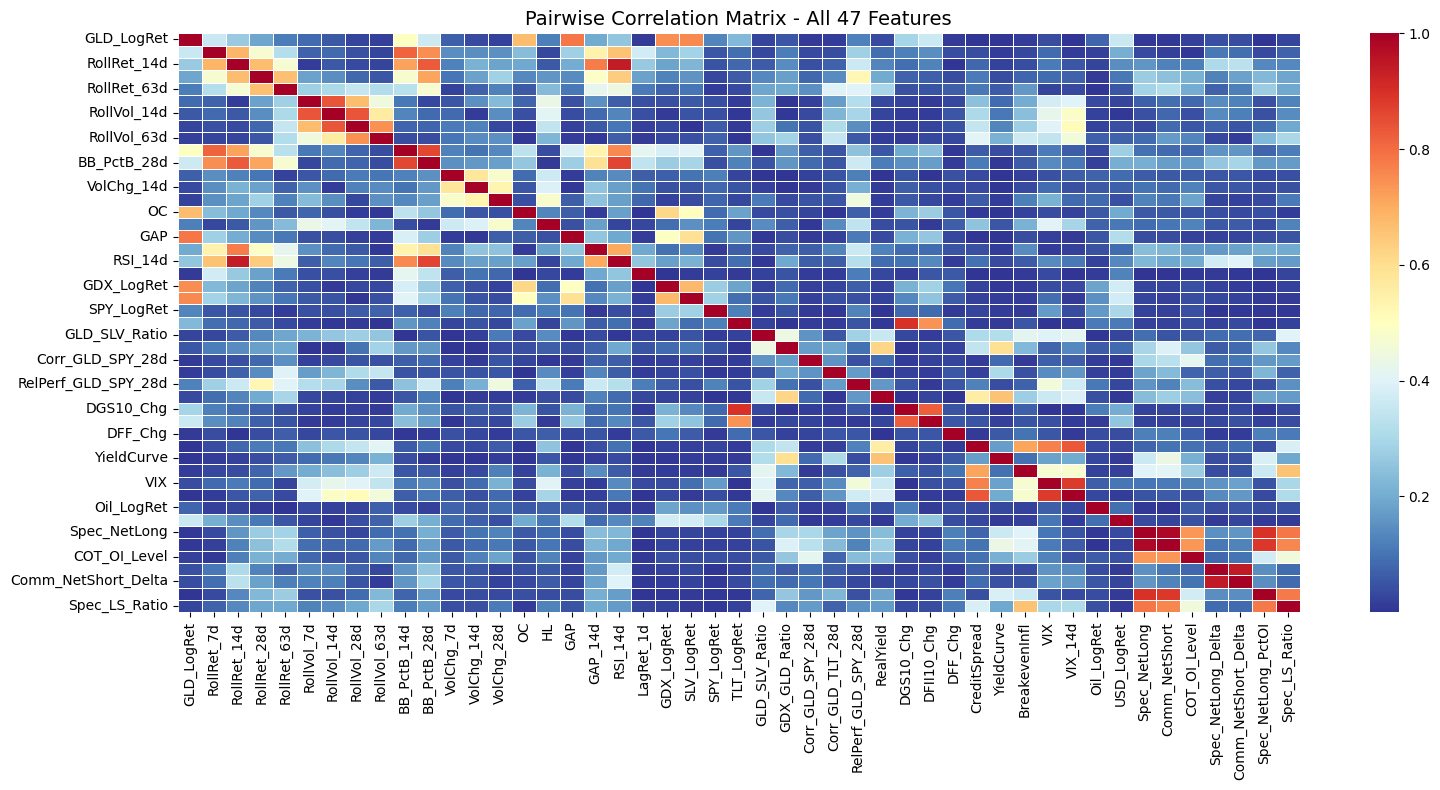

In [432]:
# Compute absolute correlation matrix
corr_matrix = X.corr().abs()

# Plot full correlation heatmap
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(corr_matrix, cmap='RdYlBu_r', center=0.5, ax=ax, linewidths=0.5)
ax.set_title('Pairwise Correlation Matrix - All 47 Features', fontsize=14)
plt.tight_layout()
plt.show()

In [434]:
# Identify pairs above threshold of 85% - highly correlated pairs
threshold = 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns to drop
to_drop_corr = [column for column in upper.columns if any(upper[column] > threshold)]

# Display correlated pairs for justification
print(f"\nCorrelation threshold: {threshold}")
print(f"Features flagged for removal: {len(to_drop_corr)}")
print(f"Features dropped: {to_drop_corr}\n")

# Show the specific pairs that triggered each drop
for col in to_drop_corr:
    correlated_with = upper.index[upper[col] > threshold].tolist()
    for pair in correlated_with:
        print(f"  {col}  <->  {pair}  (|ρ| = {corr_matrix.loc[pair, col]:.3f})")

# Drop and update feature set
X_filtered = X.drop(columns=to_drop_corr)
print(f"\nFeatures remaining after correlation filter: {X_filtered.shape[1]}")


Correlation threshold: 0.85
Features flagged for removal: 7
Features dropped: ['BB_PctB_28d', 'RSI_14d', 'DGS10_Chg', 'VIX_14d', 'Comm_NetShort', 'Comm_NetShort_Delta', 'Spec_NetLong_PctOI']

  BB_PctB_28d  <->  BB_PctB_14d  (|ρ| = 0.860)
  RSI_14d  <->  RollRet_14d  (|ρ| = 0.939)
  RSI_14d  <->  BB_PctB_28d  (|ρ| = 0.864)
  DGS10_Chg  <->  TLT_LogRet  (|ρ| = 0.895)
  VIX_14d  <->  VIX  (|ρ| = 0.881)
  Comm_NetShort  <->  Spec_NetLong  (|ρ| = 0.984)
  Comm_NetShort_Delta  <->  Spec_NetLong_Delta  (|ρ| = 0.945)
  Spec_NetLong_PctOI  <->  Spec_NetLong  (|ρ| = 0.898)
  Spec_NetLong_PctOI  <->  Comm_NetShort  (|ρ| = 0.883)

Features remaining after correlation filter: 40


The correlation filter removed 7 features at the |ρ| > 0.85 threshold, reducing the set from 47 to 40. All dropped features were mechanically or economically redundant with a retained counterpart: RSI is derived from cumulative returns, VIX_14d is a smoothed version of VIX, DGS10_Chg and TLT_LogRet both measure bond market moves, and the three CFTC positioning pairs reflect that speculator and commercial positions are mirror images by construction. No unique informational content was lost.

**ii) Wrapper Method - SHAP**

In [436]:
# Train XGBoost on the post-correlation feature set
# Default hyperparameters are used intentionally — tuning is deferred to Part C
sample_weights_shap = compute_sample_weight(class_weight='balanced', y=y)

xgb_shap = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    verbosity=0,
    eval_metric='logloss',
    random_state=42
)
xgb_shap.fit(X_filtered, y, sample_weight=sample_weights_shap)

# Compute SHAP values
explainer = shap.TreeExplainer(xgb_shap)
shap_values = explainer.shap_values(X_filtered)

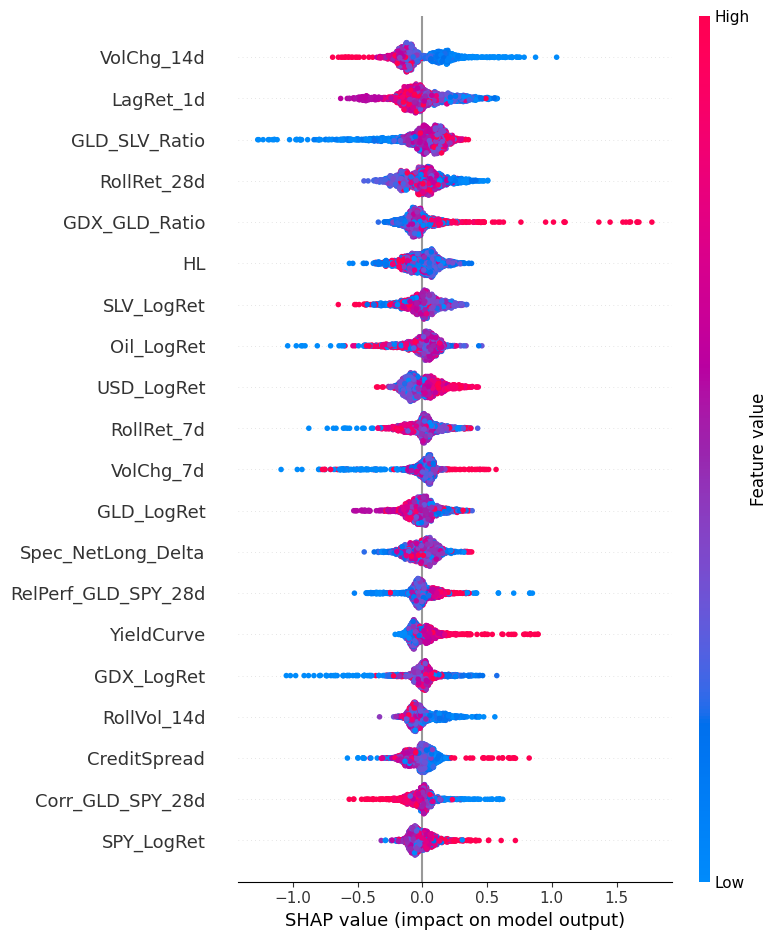

In [400]:
# Beeswarm plot — shows direction + magnitude of each feature's impact
shap.summary_plot(shap_values, X_filtered, show=True)

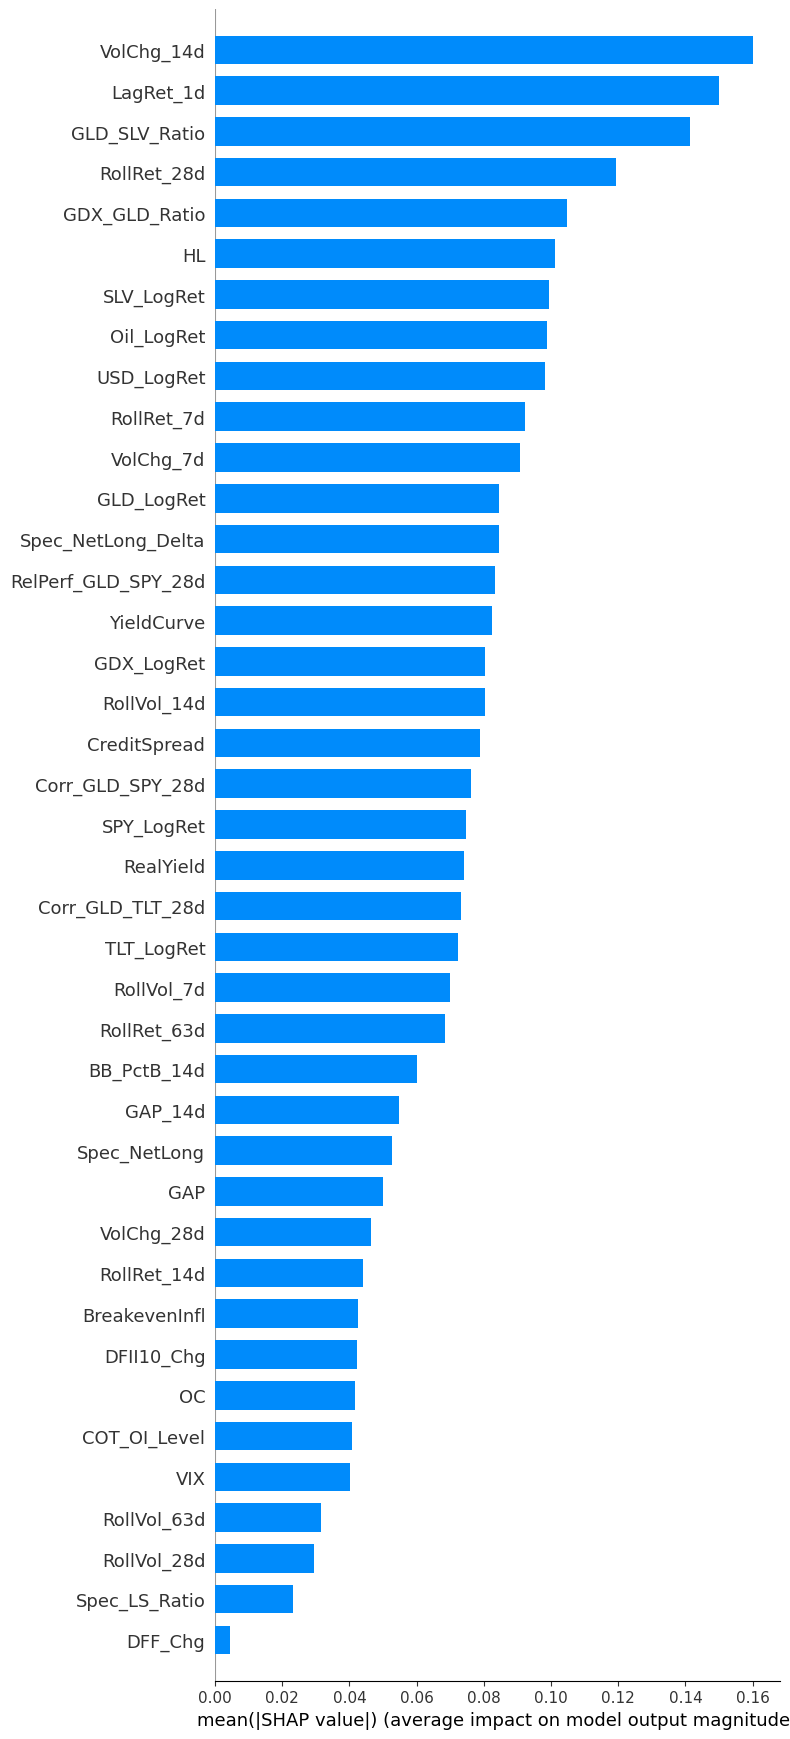

In [438]:
# Bar plot — ranks features by mean absolute SHAP value
shap.summary_plot(shap_values, X_filtered, plot_type='bar', max_display=40, show=True)

In [441]:
# Compute mean absolute SHAP values per feature
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'Feature': X_filtered.columns, 'Mean_SHAP': mean_shap}).sort_values('Mean_SHAP', ascending=False)
display(shap_df)

# Retain features with mean |SHAP| above median
shap_threshold = shap_df['Mean_SHAP'].median()
retained = shap_df[shap_df['Mean_SHAP'] >= shap_threshold]['Feature'].tolist()
dropped  = shap_df[shap_df['Mean_SHAP'] < shap_threshold]['Feature'].tolist()

print(f"\nSHAP threshold (median): {shap_threshold:.6f}")
print(f"Features retained ({len(retained)}): {retained}")
print(f"Features dropped  ({len(dropped)}): {dropped}")

X_stage2 = X_filtered[retained]
print(f"\nFeatures remaining after Stage 2 (Wrapper): {X_stage2.shape[1]}")

,Feature,Mean_SHAP
11,VolChg_14d,0.160128
17,LagRet_1d,0.149895
22,GLD_SLV_Ratio,0.141400
3,RollRet_28d,0.119418
23,GDX_GLD_Ratio,0.104602
14,HL,0.101307
19,SLV_LogRet,0.099332
34,Oil_LogRet,0.098649
35,USD_LogRet,0.098246
1,RollRet_7d,0.092107



SHAP threshold (median): 0.074375
Features retained (20): ['VolChg_14d', 'LagRet_1d', 'GLD_SLV_Ratio', 'RollRet_28d', 'GDX_GLD_Ratio', 'HL', 'SLV_LogRet', 'Oil_LogRet', 'USD_LogRet', 'RollRet_7d', 'VolChg_7d', 'GLD_LogRet', 'Spec_NetLong_Delta', 'RelPerf_GLD_SPY_28d', 'YieldCurve', 'GDX_LogRet', 'RollVol_14d', 'CreditSpread', 'Corr_GLD_SPY_28d', 'SPY_LogRet']
Features dropped  (20): ['RealYield', 'Corr_GLD_TLT_28d', 'TLT_LogRet', 'RollVol_7d', 'RollRet_63d', 'BB_PctB_14d', 'GAP_14d', 'Spec_NetLong', 'GAP', 'VolChg_28d', 'RollRet_14d', 'BreakevenInfl', 'DFII10_Chg', 'OC', 'COT_OI_Level', 'VIX', 'RollVol_63d', 'RollVol_28d', 'Spec_LS_Ratio', 'DFF_Chg']

Features remaining after Stage 2 (Wrapper): 20


SHAP analysis ranked the 40 post-filter features by their mean absolute contribution to
predictions. Applying a median threshold reduced the set from 40 to 20. Notably, most COT positioning features were eliminated, potentially due to the 4-day publication lag and as such, reducing their relevance for next-day prediction. Longer rolling windows (63d) were also dropped in favor of shorter horizons (7d, 28d), suggesting that recent momentum carries more predictive signal than intermediate trends for daily GLD moves.


iii) Embedded Method - XGBoost Gain

In [442]:
# Train XGBoost on the post-SHAP feature set
# Default hyperparameters are used intentionally — tuning is deferred to Part C
sample_weights_s3 = compute_sample_weight(class_weight='balanced', y=y)

xgb_selector = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    verbosity=0,
    eval_metric='logloss',
    random_state=42
)
xgb_selector.fit(X_stage2, y, sample_weight=sample_weights_s3)

# Extract gain-based feature importance
importance = xgb_selector.get_booster().get_score(importance_type='gain')

imp_df = pd.DataFrame({'Feature': X_stage2.columns, 'Gain': [importance.get(f, 0.0) for f in X_stage2.columns]}).sort_values('Gain', ascending=True)
imp_df.head()

,Feature,Gain
17,CreditSpread,2.300987
10,VolChg_7d,2.423482
11,GLD_LogRet,2.427167
5,HL,2.458910
14,YieldCurve,2.511343


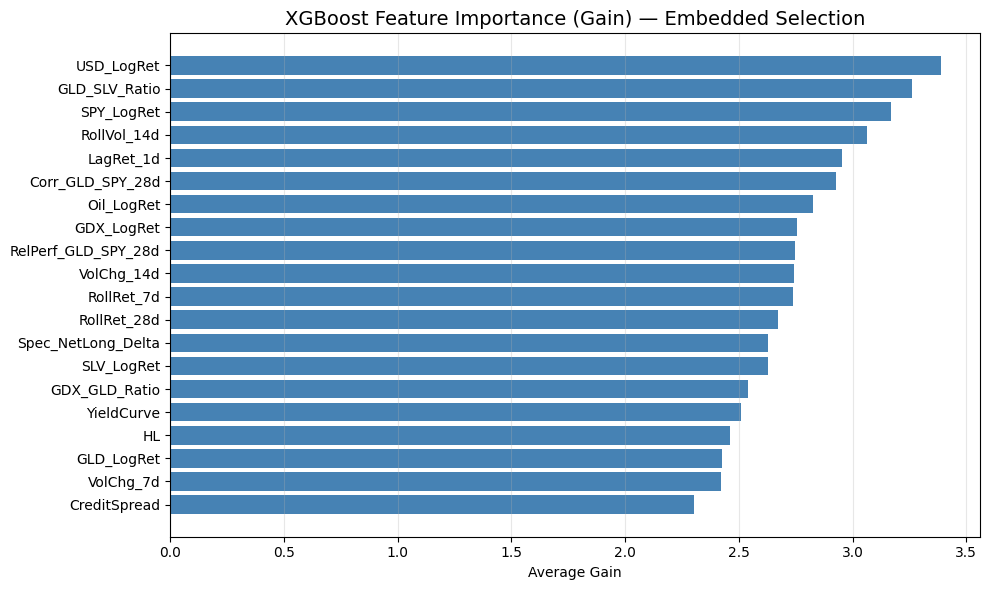

In [443]:
# Plot
fig, ax = plt.subplots(figsize=(10, max(6, len(imp_df) * 0.3)))
ax.barh(imp_df['Feature'], imp_df['Gain'], color='steelblue')
ax.set_xlabel('Average Gain')
ax.set_title('XGBoost Feature Importance (Gain) — Embedded Selection', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [444]:
# Drop features with gain below 75% of the maximum gain
max_gain = imp_df['Gain'].max()
gain_threshold = 0.75 * max_gain
to_drop_embedded = imp_df[imp_df['Gain'] < gain_threshold]['Feature'].tolist()

print(f"\nMax gain: {max_gain:.4f}")
print(f"Threshold (75% of max): {gain_threshold:.4f}")
print(f"Features dropped: {to_drop_embedded}")

X_final = X_stage2.drop(columns=to_drop_embedded)
print(f"\n=== Final feature set: {X_final.shape[1]} features ===")
print(f"Selected: {list(X_final.columns)}")


Max gain: 3.3904
Threshold (75% of max): 2.5428
Features dropped: ['CreditSpread', 'VolChg_7d', 'GLD_LogRet', 'HL', 'YieldCurve', 'GDX_GLD_Ratio']

=== Final feature set: 14 features ===
Selected: ['VolChg_14d', 'LagRet_1d', 'GLD_SLV_Ratio', 'RollRet_28d', 'SLV_LogRet', 'Oil_LogRet', 'USD_LogRet', 'RollRet_7d', 'Spec_NetLong_Delta', 'RelPerf_GLD_SPY_28d', 'GDX_LogRet', 'RollVol_14d', 'Corr_GLD_SPY_28d', 'SPY_LogRet']


The embedded stage applied a 75% of maximum gain threshold, removing 6 features whose average contribution to split decisions fell materially below the top-performing predictors. The surviving 14 features retain representation across technical (6), cross-asset (5), macro (2) and positioning (1) categories, providing the model with diverse informational inputs for Part C.


**(c) Provide the final list of selected features**

In [460]:
# create final features dataframe and print list of final features
final_df = pd.DataFrame({'Feature': X_final.columns})
print(final_df['Feature'].tolist())

['VolChg_14d', 'LagRet_1d', 'GLD_SLV_Ratio', 'RollRet_28d', 'SLV_LogRet', 'Oil_LogRet', 'USD_LogRet', 'RollRet_7d', 'Spec_NetLong_Delta', 'RelPerf_GLD_SPY_28d', 'GDX_LogRet', 'RollVol_14d', 'Corr_GLD_SPY_28d', 'SPY_LogRet']


The funnelling process reduced the original 47 engineered features to 14 through three successive stages:

| Stage | Category | Technique | Input | Retained |
|-------|----------|-----------|-----|-----|
| 1 | Filter | Pairwise Correlation (ρ > 0.85) | 47 | 40 |
| 2 | Wrapper | SHAP (median threshold) | 40 | 20 |
| 3 | Embedded | XGBoost Gain (≥ 75% of max) | 20 | 14 |

<br>
The final feature set retains representation across all four original categories:

| # | Feature | Category | Description |
|---|---------|----------|-------------|
| 1 | RollRet_7d | Technical | 7-day rolling cumulative log return |
| 2 | RollRet_28d | Technical | 28-day rolling cumulative log return |
| 3 | RollVol_14d | Technical | 14-day rolling standard deviation of daily returns |
| 4 | VolChg_14d | Technical | 14-day volume percentage change |
| 5 | LagRet_1d | Technical | 1-day lagged return |
| 6 | GLD_SLV_Ratio | Technical | Gold/silver price ratio |
| 7 | GDX_LogRet | Cross-Asset | Daily log return of GDX (gold miners ETF) |
| 8 | SLV_LogRet | Cross-Asset | Daily log return of SLV (silver ETF) |
| 9 | SPY_LogRet | Cross-Asset | Daily log return of SPY (S&P 500 ETF) |
| 10 | Corr_GLD_SPY_28d | Cross-Asset | 28-day rolling correlation GLD vs SPY |
| 11 | RelPerf_GLD_SPY_28d | Cross-Asset | GLD vs SPY cumulative return spread (28d) |
| 12 | Oil_LogRet | Macro | Daily log return of WTI crude oil |
| 13 | USD_LogRet | Macro | Daily log return of trade-weighted USD index |
| 14 | Spec_NetLong_Delta | Positioning | Weekly change in speculator net long positions |

In [452]:
# Save final feature set for Part C
features_funnelled = X_final.copy()
features_funnelled['Label'] = y
features_funnelled.to_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/features_funnelled.csv')
print(f"Saved {X_final.shape[1]} features + label to features_funnelled.csv")

Saved 14 features + label to features_funnelled.csv


### **V) Modelling**

## **C. Model Building, Tuning and Evaluation**

### **(a) Build a model to predict positive market moves (uptrend) using the feature subset derived above.**

We begin by training an XGBoost classifier with default hyperparameters on the 14 final features to establish a performance baseline. This baseline model will serve as the benchmark against other hyperparameter-tuned models in subsequent steps.

On Train/Test split design, since we are working with financial time-series data, retaining temporal order is critical. We are splitting 80/20 on training/ testing with no shuffling. Balanced sample weights are applied to compensate any class imbalance in label distribution.

In [462]:
# XGBoost
from xgboost import XGBClassifier, plot_importance, to_graphviz

# Preprocessing
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.utils.class_weight import compute_sample_weight

# Metrics
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             roc_auc_score, f1_score, precision_score, recall_score,
                             RocCurveDisplay, ConfusionMatrixDisplay,
                             PrecisionRecallDisplay, classification_report)

a) load data

In [466]:
# Load funnelled features
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/features_funnelled.csv',
                   index_col=0, parse_dates=True)

# Filter to study period: 2020-01-01 to 2025-12-31
data = data.loc['2020':'2025']

b) Train-Test Split

In [467]:
# Separate features and label
X = data.drop(columns=['Label'])
y = data['Label'].values

# Train-test split (80/20, chronological)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# output the train test data date range and size
print(f"Training set: {len(X_train)} rows ({X_train.index.min().date()} to {X_train.index.max().date()})")
print(f"Test set:     {len(X_test)} rows ({X_test.index.min().date()} to {X_test.index.max().date()})")
print(f"Features:     {X.shape[1]}")

Training set: 1204 rows (2020-01-02 to 2024-10-16)
Test set:     301 rows (2024-10-17 to 2025-12-30)
Features:     14


c) Fit Baseline Model

In [465]:
# Balanced sample weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Base XGBoost model with default parameters
base_model = XGBClassifier(
    verbosity=0,
    eval_metric='logloss'
)


Train Accuracy:        1.0000
Test Accuracy:         0.5150
Test Balanced Accuracy:0.5147
Test ROC-AUC:          0.5119


d) Predict Baseline Model

In [469]:
# Fit
base_model.fit(X_train, y_train, sample_weight=sample_weights)

# Predict
y_pred = base_model.predict(X_test)
y_proba = base_model.predict_proba(X_test)

# Metrics
acc_train = accuracy_score(y_train, base_model.predict(X_train))
acc_test  = accuracy_score(y_test, y_pred)
bal_acc_test = balanced_accuracy_score(y_test, y_pred)
auc_test  = roc_auc_score(y_test, y_proba[:, 1])

print(f"Train Accuracy:        {acc_train:.4f}")
print(f"Test Accuracy:         {acc_test:.4f}")
print(f"Test Balanced Accuracy:{bal_acc_test:.4f}")
print(f"Test ROC-AUC:          {auc_test:.4f}")

Train Accuracy:        1.0000
Test Accuracy:         0.5150
Test Balanced Accuracy:0.5147
Test ROC-AUC:          0.5119


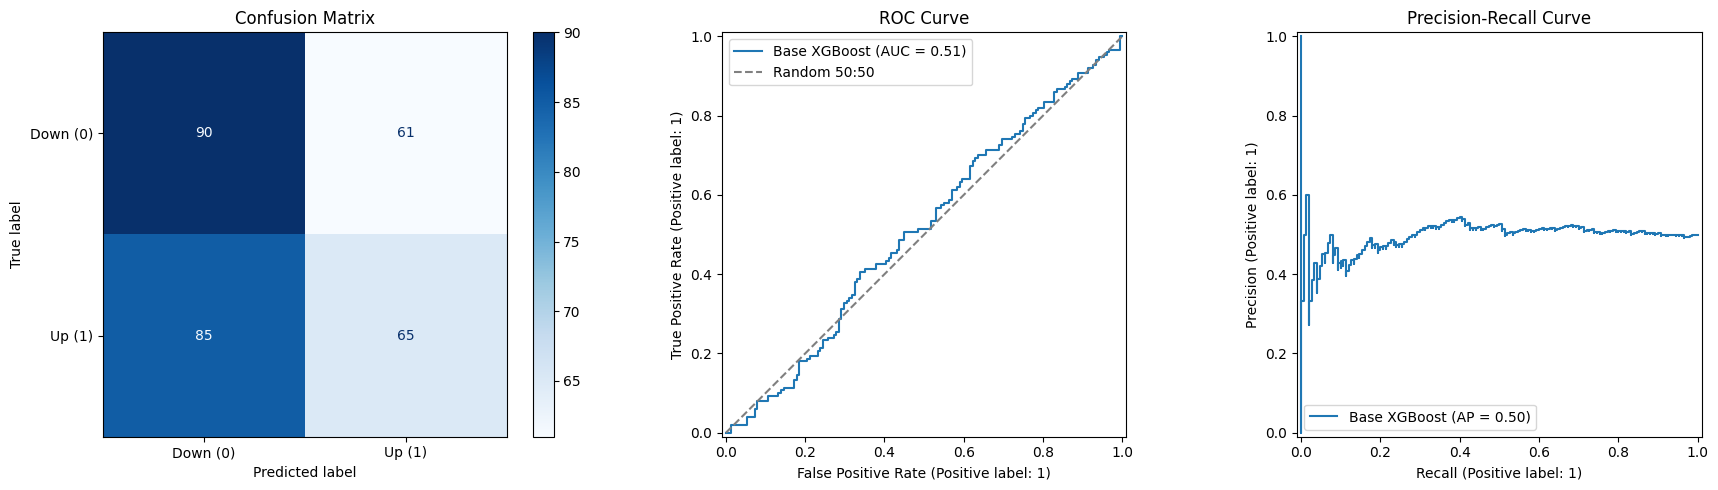

              precision    recall  f1-score   support

    Down (0)       0.51      0.60      0.55       151
      Up (1)       0.52      0.43      0.47       150

    accuracy                           0.51       301
   macro avg       0.52      0.51      0.51       301
weighted avg       0.52      0.51      0.51       301



In [470]:
# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_estimator(
    base_model, X_test, y_test,
    display_labels=['Down (0)', 'Up (1)'],
    cmap=plt.cm.Blues, ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

# ROC Curve
RocCurveDisplay.from_estimator(
    base_model, X_test, y_test,
    name='Base XGBoost', ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random 50:50')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(
    base_model, X_test, y_test,
    name='Base XGBoost', ax=axes[2]
)
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

# Classification Report
print(classification_report(y_test, y_pred, target_names=['Down (0)', 'Up (1)']))

The base model achieves perfect training accuracy (1.00) but only 51.5% test accuracy and a ROC-AUC of 0.51, indicating severe overfitting. With default parameters (`max_depth=6`, `n_estimators=100`) the model basically memorized model’s training data, but unable to generalize the model to predict unseen observations. The confusion matrix reveals a slight bias toward predicting Down (175 vs 126 Up predictions), with roughly equal misclassification rates across both classes. This is within expectations before parameters tuning.

### **(b) Tune the hyperparameters of the estimator to obtain an optimal model.**

Hyperparameters Tuning

The base model's perfect training accuracy and near-random test performance indicates severe overfitting. To regularise the model and improve generalisation, we tune six key XGBoost hyperparameters:

| Parameter | Role | Search Range |
|-----------|------|-------------|
| `learning_rate` | Step size shrinkage per boosting round | 0.01, 0.05, 0.10, 0.15, 0.20, 0.30 |
| `max_depth` | Maximum tree depth — controls model complexity | 3, 4, 5, 6, 8 |
| `min_child_weight` | Minimum sum of instance weight in a child node | 1, 3, 5, 7, 10 |
| `gamma` | Minimum loss reduction for a further split — acts as pruning penalty | 0.0, 0.1, 0.2, 0.3, 0.5, 1.0 |
| `colsample_bytree` | Fraction of features sampled per tree | 0.3, 0.4, 0.5, 0.7, 1.0 |
| `n_estimators` | Number of boosting rounds | 100, 200, 300, 500 |

Cross-validation uses `TimeSeriesSplit` with 5 folds, which ensures that training data always precedes test data temporally — preventing future information leakage. The search is performed using `RandomizedSearchCV` with 50 iterations, scored on ROC-AUC.

In [492]:
# Hyperparameter search space
param_distributions = {
    'learning_rate':    [0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
    'max_depth':        [3, 4, 5, 6, 8, 10, 12, 15],
    'min_child_weight': [1, 3, 5, 7],
    'gamma':            [0.0, 0.1, 0.2, 0.3, 0.4],
    'colsample_bytree': [0.3, 0.4, 0.5, 0.7],
    'n_estimators':     [100, 200, 300],
}

tscv = TimeSeriesSplit(n_splits=5)

xgb_estimator = XGBClassifier(verbosity=0, eval_metric='logloss')
xgb_estimator.set_fit_request(sample_weight=True)

search = RandomizedSearchCV(
    estimator=xgb_estimator,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='roc_auc',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train, sample_weight=sample_weights)

print(f"\nBest ROC-AUC (CV): {search.best_score_:.4f}")
print(f"\nBest parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best ROC-AUC (CV): 0.5370

Best parameters:
  n_estimators: 300
  min_child_weight: 7
  max_depth: 10
  learning_rate: 0.1
  gamma: 0.4
  colsample_bytree: 0.7


In [493]:
# Retrain with best parameters + eval_set for loss tracking
best_params = search.best_params_

tuned_model = XGBClassifier(
    **best_params,
    verbosity=0,
    eval_metric='logloss'
)

tuned_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# Predict
y_pred_tuned  = tuned_model.predict(X_test)
y_proba_tuned = tuned_model.predict_proba(X_test)

# Metrics
acc_train_t = accuracy_score(y_train, tuned_model.predict(X_train))
acc_test_t  = accuracy_score(y_test, y_pred_tuned)
bal_acc_t   = balanced_accuracy_score(y_test, y_pred_tuned)
auc_t       = roc_auc_score(y_test, y_proba_tuned[:, 1])

print(f"Train Accuracy:         {acc_train_t:.4f}")
print(f"Test Accuracy:          {acc_test_t:.4f}")
print(f"Test Balanced Accuracy: {bal_acc_t:.4f}")
print(f"Test ROC-AUC:           {auc_t:.4f}")
print(f"\nImprovement over base:  AUC {auc_t - 0.5119:+.4f}")

Train Accuracy:         0.9934
Test Accuracy:          0.5017
Test Balanced Accuracy: 0.5015
Test ROC-AUC:           0.5205

Improvement over base:  AUC +0.0086


In [494]:
# Cross-validation score with tuned model
cv_scores = cross_val_score(tuned_model, X_train, y_train, cv=tscv, scoring='roc_auc')
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Mean CV ROC-AUC: 0.5231 (+/- 0.0686)


### **(c) Evaluate the model's prediction quality using the area under the receiver operating characteristic (ROC) curve, confusion matrix, and classification report.**

We now evaluate the tuned model using the same metrics applied to the base model: confusion matrix, ROC curve, precision-recall curve, and classification report. Feature importance by gain is also examined to understand which features the tuned model relies on most.

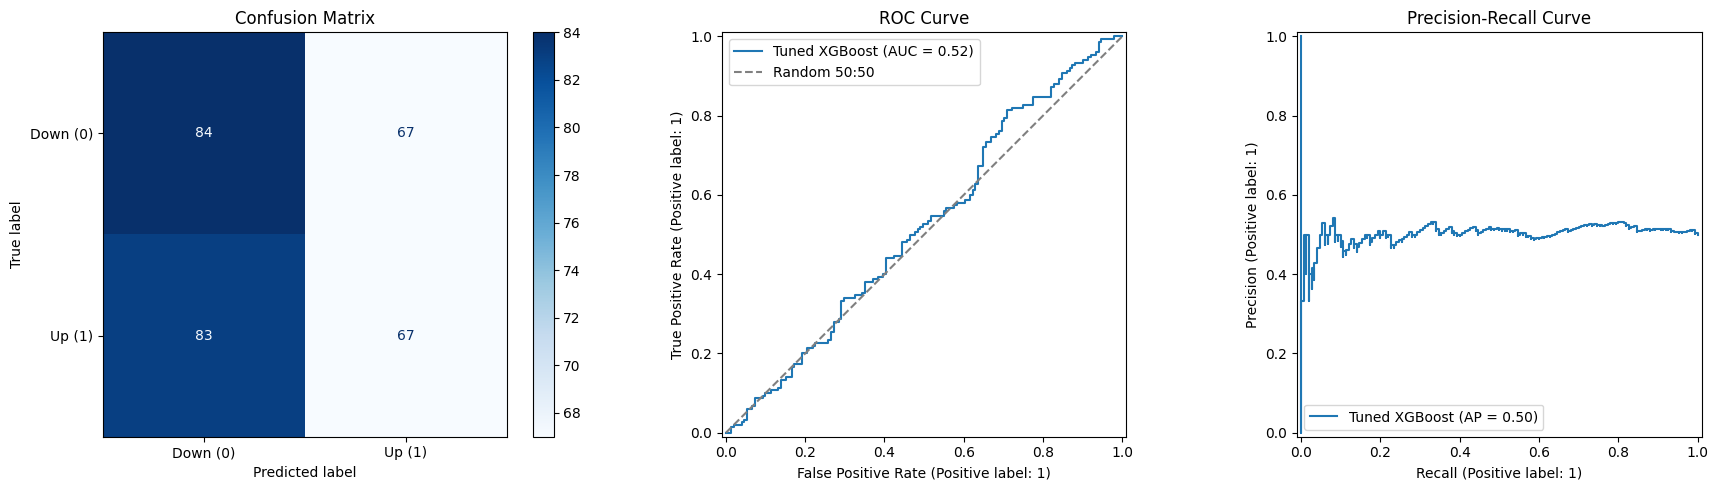

              precision    recall  f1-score   support

    Down (0)       0.50      0.56      0.53       151
      Up (1)       0.50      0.45      0.47       150

    accuracy                           0.50       301
   macro avg       0.50      0.50      0.50       301
weighted avg       0.50      0.50      0.50       301



In [495]:
# Tuned Model Evaluation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    tuned_model, X_test, y_test,
    display_labels=['Down (0)', 'Up (1)'],
    cmap=plt.cm.Blues, ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

# ROC Curve
RocCurveDisplay.from_estimator(
    tuned_model, X_test, y_test,
    name='Tuned XGBoost', ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random 50:50')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(
    tuned_model, X_test, y_test,
    name='Tuned XGBoost', ax=axes[2]
)
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_tuned, target_names=['Down (0)', 'Up (1)']))

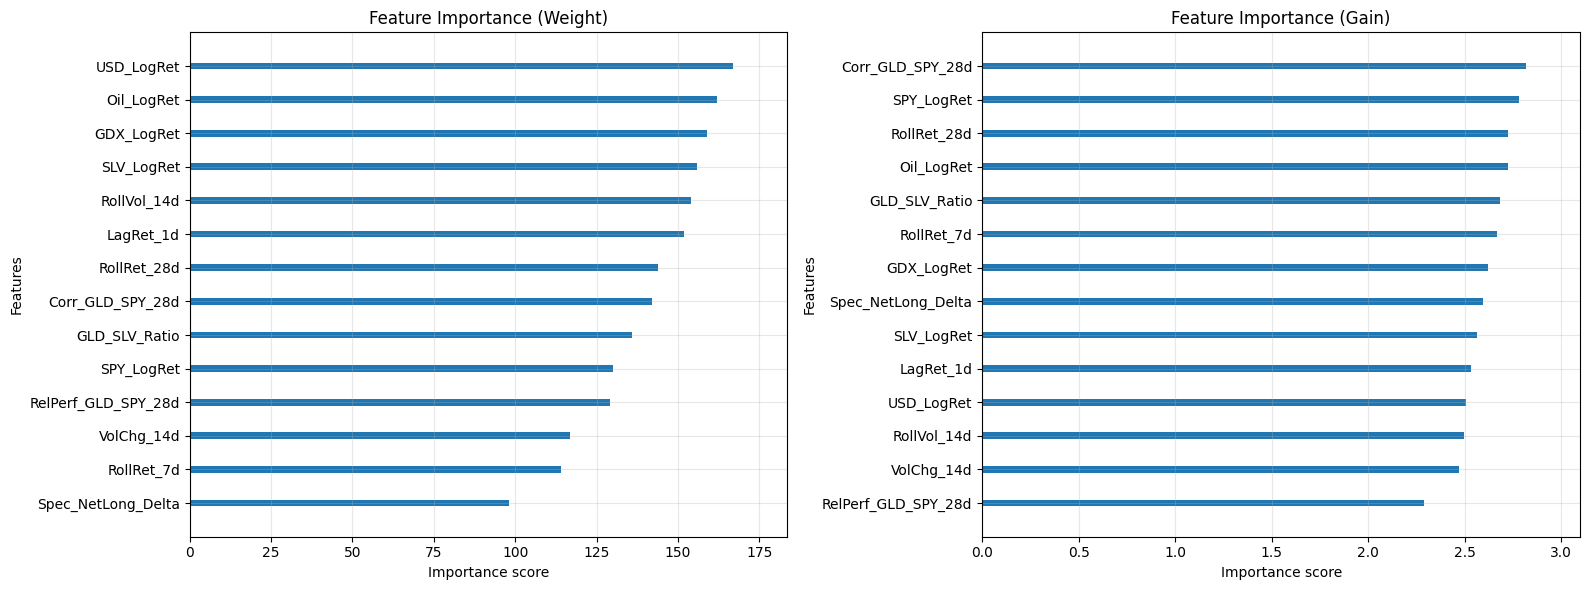

In [496]:
# Feature Importance by Gain
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_importance(tuned_model, importance_type='weight', ax=axes[0], show_values=False)
axes[0].set_title('Feature Importance (Weight)')
axes[0].grid(True, alpha=0.3)

plot_importance(tuned_model, importance_type='gain', ax=axes[1], show_values=False)
axes[1].set_title('Feature Importance (Gain)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The tuned model achieves a test ROC-AUC of 0.52, a marginal improvement over the base model (0.51) and the random classifier baseline. The confusion matrix shows 84+67 = 151 correct predictions out of 301 (50.2%), with a slight bias toward predicting Down (167 Down vs 134 Up predictions). Precision is symmetric at 0.50 for both classes, confirming the model has limited discriminative power on out-of-sample data.

The modest performance is consistent with efficient market conditions for a highly liquid instrument like GLD. Daily gold returns exhibit a low signal-to-noise ratio, and the exam introduction notes that "efficient markets produce near-normal daily returns with no significant correlation." The regularisation did succeed in narrowing the train-test gap from 1.00/0.51 (base) to 0.99/0.52 (tuned), confirming overfitting was reduced even if predictive power remains marginal.

**Feature Importance**

The gain chart — which measures the average improvement in the objective function per split — reveals that cross-asset and momentum features dominate:

| Rank | Feature | Category | Interpretation |
|------|---------|----------|---------------|
| 1 | Corr_GLD_SPY_28d | Cross-Asset | Gold-equity correlation regime is the strongest signal |
| 2 | SPY_LogRet | Cross-Asset | Equity market direction informs gold positioning |
| 3 | RollRet_28d | Technical | Monthly momentum captures trend persistence |
| 4 | Oil_LogRet | Macro | Commodity complex co-movement |
| 5 | GLD_SLV_Ratio | Technical | Precious metals relative value |

The weight chart (frequency of use across splits) is more evenly distributed, with USD_LogRet and Oil_LogRet appearing most often. The divergence between weight and gain rankings is typical — a feature can be used frequently for small refinements (high weight) while another is used less often but produces larger information gain per split.

Notably, the positioning feature (Spec_NetLong_Delta) ranks last by weight but mid-table by gain, suggesting that when COT data does contribute, it provides meaningful signal — but its weekly granularity limits how often the model can exploit it.